#Cell 1: Mount Google Drive & Extract Dataset

In [11]:
# ── 1. Mount Drive ────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── 2. Imports ────────────────────────────────────────────────────────────────
import os, zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ── 3. Paths ──────────────────────────────────────────────────────────────────
ZIP_PATH     = "/content/drive/MyDrive/CVPR/AMCD"          # zip in Drive
EXTRACT_PATH = "/content/drive/MyDrive/CVPR/AMCD_dataset"  # extracted to Drive (persists)
DATASET_PATH = EXTRACT_PATH                                 # use this in the rest of your notebook

# ── 4. Extract ONCE — skips if already done ───────────────────────────────────
if os.path.exists(EXTRACT_PATH) and os.listdir(EXTRACT_PATH):
    print("✅ Dataset already extracted — skipping unzip.")
else:
    print("📦 Extracting dataset to Drive (this only happens once)…")
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_PATH)
    print("✅ Extraction complete!")

# ── 5. Sanity-check: print top-level folder structure ────────────────────────
print(f"\nDataset root: {DATASET_PATH}")
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    if level > 2:
        continue
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 2:
        print(f"{'  ' * (level+1)}({len(files)} files)")

# ── 6. Device ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥  Using device: {device}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset already extracted — skipping unzip.

Dataset root: /content/drive/MyDrive/CVPR/AMCD_dataset
AMCD_dataset/
  Multi-Source Agricultural Image Dataset for Robust Classification and Semantic Segmentation/
    Crops or Grains/
      (0 files)
    Flowers/
      (0 files)
    Fruits/
      (0 files)
    Vegetables/
      (0 files)

🖥  Using device: cuda


#Fix applied: Dataset structure
Your images live TWO levels deep (`Category/Species/*.jpg`), not one:

```
AMCD_dataset/
  Multi-Source .../          <- not a class
    Crops or Grains/         <- category, NOT a class
      Chickpeas/ *.jpg       <- actual class
      Corn/ *.jpg            <- actual class
    Flowers/                 <- category, NOT a class
      Brunfelsia/ *.jpg      <- actual class
      ...
    Fruits/
    Vegetables/
```

`ImageFolder` only looks **one level deep** for classes, so pointing it at
`DATASET_PATH` merged everything into 1 class, and an earlier auto-detect
that just picked "the folder with the most subfolders" silently **kept only
one category (e.g. Flowers) and dropped Crops, Fruits, and Vegetables
entirely** — a real data-loss bug, not just a crash.

**Fix:** symlink every species folder (regardless of which category it's
nested under) into one flat directory, so every species from every category
becomes a top-level class.

In [12]:
# ── Dataset Structure Fix — Flatten Nested Categories into Classes ───────────
import os, shutil

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

def find_leaf_class_dirs(base_path):
    """A 'leaf' class dir directly contains images and has no subfolders."""
    leaves = []
    for root, dirs, files in os.walk(base_path):
        has_images = any(os.path.splitext(f)[1].lower() in IMG_EXTS for f in files)
        if has_images and not dirs:
            leaves.append(root)
    return leaves

def build_flat_classes(base_path, flat_root):
    """
    Symlinks every leaf species folder into `flat_root` as a top-level class,
    so ImageFolder(root=flat_root) sees ALL species from every category.
    De-duplicates same-name species across categories by prefixing the
    category name (e.g. two different 'Rose' folders under different
    categories become 'Flowers_Rose', 'Vegetables_Rose').
    """
    if os.path.exists(flat_root):
        shutil.rmtree(flat_root)             # rebuild fresh — symlinks are cheap
    os.makedirs(flat_root, exist_ok=True)

    leaf_dirs = find_leaf_class_dirs(base_path)
    seen = {}

    for leaf in leaf_dirs:
        class_name = os.path.basename(leaf)
        if class_name in seen:
            parent     = os.path.basename(os.path.dirname(leaf))
            class_name = f"{parent}_{class_name}"
        seen[class_name] = leaf
        os.symlink(leaf, os.path.join(flat_root, class_name))

    return flat_root, sorted(seen.keys())


# ── 1. Scan structure (visual confirmation) ───────────────────────────────────
print("🔍 Scanning dataset structure …\n")
for root, dirs, files in os.walk(DATASET_PATH):
    level  = root.replace(DATASET_PATH, '').count(os.sep)
    if level > 2:
        continue
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")

# ── 2. Flatten every species across every category ────────────────────────────
FLAT_ROOT = "/content/AMCD_flat"
correct_root, discovered_classes = build_flat_classes(DATASET_PATH, FLAT_ROOT)

print(f"\n✅ Flattened dataset root : {correct_root}")
print(f"   Total species/classes  : {len(discovered_classes)}")
print(f"   {discovered_classes}")


🔍 Scanning dataset structure …

AMCD_dataset/
  Multi-Source Agricultural Image Dataset for Robust Classification and Semantic Segmentation/
    Crops or Grains/
    Flowers/
    Fruits/
    Vegetables/

✅ Flattened dataset root : /content/AMCD_flat
   Total species/classes  : 77
   ['Apple', 'Banana', 'Beans', 'Beetroot', 'Bitter Gourd', 'Bottle Gourd', 'Brunfelsia', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Chickpeas', 'China Rose', 'Chinese Ixora', 'Chrysanthemum', 'Cockscomb', 'Coriander', 'Corn', 'Custard Apple', 'Dahlia', 'Damask Rose', 'Dates', 'Eggplant', 'Garden Rose', 'Garden Rose White', 'Genda', 'Grapes', 'Green Coconut', 'Green chili', 'Hibiscus', 'Ixora Coccinea', 'Jackfruit', 'Jamun', 'Linseed', 'Lychee', 'Mango', 'Marigold', 'Muskmelon', 'Mustard', 'Peace Rose', 'Pear', 'Pineapple', 'Pointed Gourd', 'Pomegranate', 'Pomelo', 'Potato', 'Pumpkin', 'Radish', 'Rangoon Creeper', 'Red Amaranth', 'Red Lentil', 'Rice', 'Rose Kristall', 'Rose Landora', 'Rose Veterans Honor

#Preprocessing & Augmentation

Classes  (77): ['Apple', 'Banana', 'Beans', 'Beetroot', 'Bitter Gourd', 'Bottle Gourd', 'Brunfelsia', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Chickpeas', 'China Rose', 'Chinese Ixora', 'Chrysanthemum', 'Cockscomb', 'Coriander', 'Corn', 'Custard Apple', 'Dahlia', 'Damask Rose', 'Dates', 'Eggplant', 'Garden Rose', 'Garden Rose White', 'Genda', 'Grapes', 'Green Coconut', 'Green chili', 'Hibiscus', 'Ixora Coccinea', 'Jackfruit', 'Jamun', 'Linseed', 'Lychee', 'Mango', 'Marigold', 'Muskmelon', 'Mustard', 'Peace Rose', 'Pear', 'Pineapple', 'Pointed Gourd', 'Pomegranate', 'Pomelo', 'Potato', 'Pumpkin', 'Radish', 'Rangoon Creeper', 'Red Amaranth', 'Red Lentil', 'Rice', 'Rose Kristall', 'Rose Landora', 'Rose Veterans Honor', 'Sacred Tree', 'Safflower', 'Sapodilla', 'Scarlet Sage', 'Shoeblack', 'Silver flower', 'Spiny Gourd', 'Sponge Gourd', 'Strawberry', 'Sunflower', 'Sweet Orange', 'Tangerine', 'Taro leaves', 'Tomato', 'Turnip', 'Watermelon', 'Wax Gourd', 'Wheat', 'Yardlong beans', 'Ye

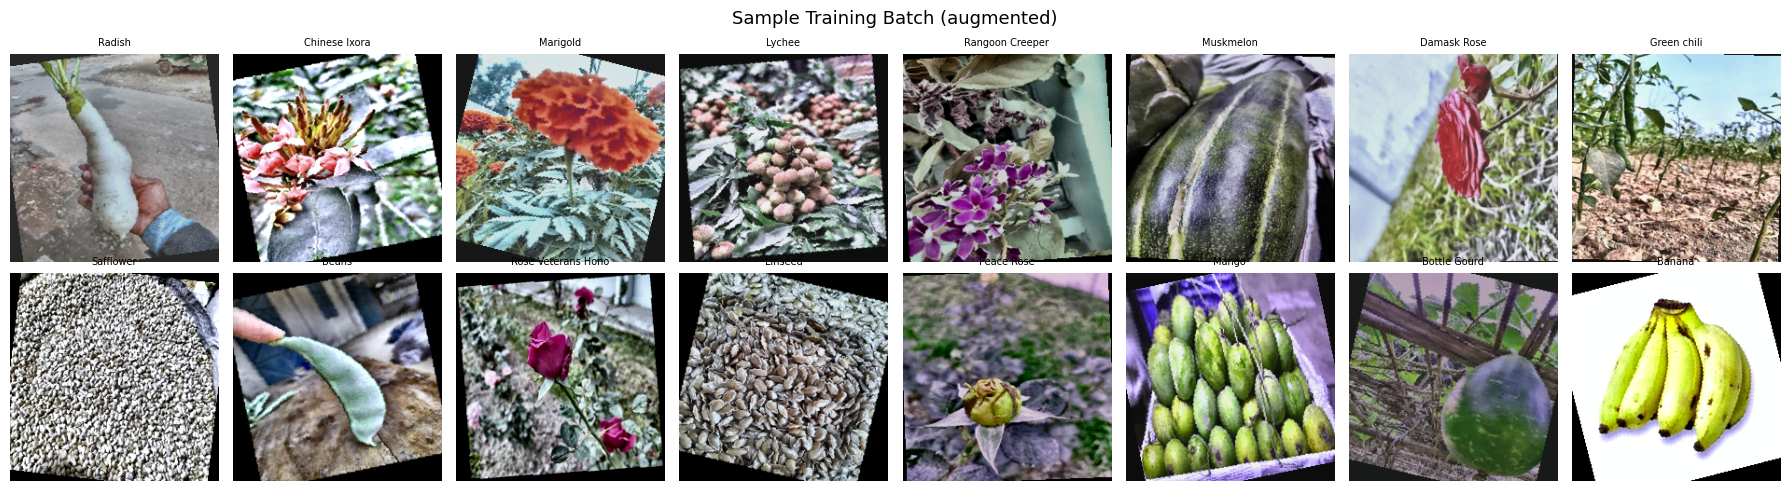


Image tensor shape : torch.Size([32, 3, 224, 224])
Label tensor shape : torch.Size([32])


In [13]:
# ── Preprocessing & Augmentation ─────────────────────────────────────────────

# ── ImageNet stats (standard for pretrained models) ───────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

# ── Train transform  (augmentation + normalization) ───────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),          # Resize to 224×224
    transforms.RandomHorizontalFlip(p=0.5),           # Horizontal Flip  (50 % chance)
    transforms.RandomRotation(degrees=15),            # Rotation  ±15°
    transforms.ColorJitter(                           # Color Jitter
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.ToTensor(),                            # [0,255] HWC  →  [0,1] CHW
    transforms.Normalize(mean=MEAN, std=STD),         # Normalization
])

# ── Val / Test transform  (no augmentation, only resize + normalize) ──────────
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# ── Load dataset from the FLATTENED root (correct_root, from the fix cell) ───
full_dataset = datasets.ImageFolder(root=correct_root, transform=train_transform)

NUM_CLASSES  = len(full_dataset.classes)
CLASS_NAMES  = full_dataset.classes
print(f"Classes  ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Total images      : {len(full_dataset)}")

# ── Train / Val / Test split  (70 / 15 / 15) ─────────────────────────────────
total      = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)   # reproducible split
)

# Apply val/test transform (no augmentation) — same flattened root ────────────
val_set.dataset  = datasets.ImageFolder(root=correct_root, transform=val_transform)
test_set.dataset = datasets.ImageFolder(root=correct_root, transform=val_transform)

print(f"\nTrain : {len(train_set)} images")
print(f"Val   : {len(val_set)}   images")
print(f"Test  : {len(test_set)}  images")

# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 2   # safe default for Colab

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nBatch size : {BATCH_SIZE}")
print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

# ── Quick sanity check: visualise one batch ───────────────────────────────────
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle("Sample Training Batch (augmented)", fontsize=13)

for i, ax in enumerate(axes.flatten()):
    if i >= len(images):
        ax.axis('off')
        continue
    # Denormalise for display
    img = images[i].permute(1, 2, 0).numpy()
    img = img * STD + MEAN
    img = img.clip(0, 1)
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i]][:18], fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nImage tensor shape : {images.shape}")   # [B, 3, 224, 224]
print(f"Label tensor shape : {labels.shape}")    # [B]


#EfficientNet-B3 Backbone
(pretrained, fine-tuned)

In [14]:
# ── EfficientNet-B3 Backbone (Pretrained + Fine-Tuned) ───────────────────────
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

# ── 1. Load pretrained backbone ───────────────────────────────────────────────
weights = EfficientNet_B3_Weights.IMAGENET1K_V1
model   = efficientnet_b3(weights=weights)

# ── 2. Freeze all backbone layers first ───────────────────────────────────────
for param in model.parameters():
    param.requires_grad = False

# ── 3. Fine-tune strategy: Unfreeze last 2 blocks (blocks 6 & 7) ──────────────
#    EfficientNet-B3 features = [block0 … block7]  +  Conv head
UNFREEZE_FROM = 6   # unfreeze blocks 6, 7 + head

for i, block in enumerate(model.features):
    if i >= UNFREEZE_FROM:
        for param in block.parameters():
            param.requires_grad = True

# ── 4. Replace classifier head for NUM_CLASSES ────────────────────────────────
#    Default head:  Dropout(p=0.3)  →  Linear(1536, 1000)
in_features = model.classifier[1].in_features   # 1536 for B3

model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_features, 512),
    nn.SiLU(),                                   # same activation as EfficientNet body
    nn.Dropout(p=0.3),
    nn.Linear(512, NUM_CLASSES)                  # final logits
)

model = model.to(device)

# ── 5. Parameter summary ──────────────────────────────────────────────────────
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params   = total_params - trainable_params

print("=" * 52)
print("       EfficientNet-B3  —  Parameter Summary")
print("=" * 52)
print(f"  Total params     : {total_params:>12,}")
print(f"  Trainable params : {trainable_params:>12,}  ✅")
print(f"  Frozen params    : {frozen_params:>12,}  🔒")
print(f"  Trainable ratio  : {100 * trainable_params / total_params:>11.1f} %")
print("=" * 52)

# ── 6. Per-layer trainability overview ────────────────────────────────────────
print("\nLayer-wise freeze status:")
print(f"  {'Layer':<30} {'Trainable':>10}")
print("  " + "-" * 42)

for name, module in model.named_children():
    if name == "features":
        for i, block in enumerate(module):
            trainable = any(p.requires_grad for p in block.parameters())
            status    = "✅ unfrozen" if trainable else "🔒 frozen"
            print(f"  features[{i}] {str(type(block).__name__):<20} {status}")
    else:
        trainable = any(p.requires_grad for p in module.parameters())
        status    = "✅ unfrozen" if trainable else "🔒 frozen"
        print(f"  {name:<30} {status}")

# ── 7. Verify output shape with a dummy forward pass ─────────────────────────
model.eval()
with torch.no_grad():
    dummy  = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    output = model(dummy)

print(f"\n✅ Forward pass OK")
print(f"   Input  shape : {list(dummy.shape)}")
print(f"   Output shape : {list(output.shape)}   → [{NUM_CLASSES} classes]")


       EfficientNet-B3  —  Parameter Summary
  Total params     :   11,522,677
  Trainable params :    9,332,523  ✅
  Frozen params    :    2,190,154  🔒
  Trainable ratio  :        81.0 %

Layer-wise freeze status:
  Layer                           Trainable
  ------------------------------------------
  features[0] Conv2dNormActivation 🔒 frozen
  features[1] Sequential           🔒 frozen
  features[2] Sequential           🔒 frozen
  features[3] Sequential           🔒 frozen
  features[4] Sequential           🔒 frozen
  features[5] Sequential           🔒 frozen
  features[6] Sequential           ✅ unfrozen
  features[7] Sequential           ✅ unfrozen
  features[8] Conv2dNormActivation ✅ unfrozen
  avgpool                        🔒 frozen
  classifier                     ✅ unfrozen

✅ Forward pass OK
   Input  shape : [2, 3, 224, 224]
   Output shape : [2, 77]   → [77 classes]


#★ CBAM Attention Module
(channel + spatial attention)

In [15]:
# ── CBAM Attention Module (Channel + Spatial Attention) ──────────────────────

# ── 1. Channel Attention Module ───────────────────────────────────────────────
class ChannelAttention(nn.Module):
    """
    Squeeze-and-Excitation style channel attention.
    Learns WHICH feature channels to emphasise.

    Flow:  x → AvgPool + MaxPool → shared MLP → sigmoid gate → x * gate
    """
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()

        bottleneck = max(in_channels // reduction_ratio, 8)   # floor at 8

        self.shared_mlp = nn.Sequential(
            nn.Linear(in_channels, bottleneck, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(bottleneck, in_channels, bias=False),
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, H, W = x.shape

        avg_pool = x.mean(dim=[2, 3])
        max_pool = x.amax(dim=[2, 3])

        avg_out  = self.shared_mlp(avg_pool)
        max_out  = self.shared_mlp(max_pool)

        gate = self.sigmoid(avg_out + max_out).view(B, C, 1, 1)

        return x * gate


# ── 2. Spatial Attention Module ───────────────────────────────────────────────
class SpatialAttention(nn.Module):
    """
    Learns WHERE (which spatial locations) to focus.

    Flow:  x → channel-wise AvgPool + MaxPool → concat → Conv → sigmoid gate → x * gate
    """
    def __init__(self, kernel_size=7):
        super().__init__()

        assert kernel_size in (3, 7), "kernel_size must be 3 or 7"
        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            in_channels=2,
            out_channels=1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_pool = x.mean(dim=1, keepdim=True)
        max_pool = x.amax(dim=1, keepdim=True)

        pooled = torch.cat([avg_pool, max_pool], dim=1)

        gate = self.sigmoid(self.conv(pooled))

        return x * gate


# ── 3. Full CBAM Block ────────────────────────────────────────────────────────
class CBAM(nn.Module):
    """
    Convolutional Block Attention Module (Woo et al., ECCV 2018).
    Applies Channel Attention → Spatial Attention sequentially.
    """
    def __init__(self, in_channels, reduction_ratio=16, kernel_size=7):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_att = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x


# ── 4. Integrate CBAM into EfficientNet-B3 ───────────────────────────────────
class EfficientNetB3_CBAM(nn.Module):
    """
    EfficientNet-B3 backbone with CBAM injected after the last
    feature block (features[8]) — just before global pooling.
    """
    def __init__(self, backbone, num_classes, reduction_ratio=16):
        super().__init__()

        self.features   = backbone.features
        self.cbam       = CBAM(in_channels=1536, reduction_ratio=reduction_ratio)
        self.avgpool    = backbone.avgpool
        self.classifier = backbone.classifier

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# ── 5. Build final model ──────────────────────────────────────────────────────
model_cbam = EfficientNetB3_CBAM(
    backbone    = model,
    num_classes = NUM_CLASSES,
    reduction_ratio = 16
).to(device)

# ── 6. Parameter summary ──────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model_cbam.parameters())
trainable_params = sum(p.numel() for p in model_cbam.parameters() if p.requires_grad)
cbam_params      = sum(p.numel() for p in model_cbam.cbam.parameters())
frozen_params    = total_params - trainable_params

print("=" * 56)
print("   EfficientNet-B3 + CBAM  —  Parameter Summary")
print("=" * 56)
print(f"  Total params       : {total_params:>12,}")
print(f"  Trainable params   : {trainable_params:>12,}  ✅")
print(f"  Frozen params      : {frozen_params:>12,}  🔒")
print(f"  CBAM-only params   : {cbam_params:>12,}  🎯")
print(f"  Trainable ratio    : {100 * trainable_params / total_params:>11.1f} %")
print("=" * 56)

# ── 7. Verify forward pass + attention map shapes ─────────────────────────────
model_cbam.eval()
with torch.no_grad():
    dummy  = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    feat   = model_cbam.features(dummy)
    ch_out = model_cbam.cbam.channel_att(feat)
    sp_out = model_cbam.cbam.spatial_att(ch_out)
    final  = model_cbam(dummy)

print(f"\n✅ Forward pass OK")
print(f"\n  {'Stage':<35} {'Shape'}")
print("  " + "-" * 55)
print(f"  {'Input':<35} {list(dummy.shape)}")
print(f"  {'After EfficientNet features':<35} {list(feat.shape)}")
print(f"  {'After Channel Attention':<35} {list(ch_out.shape)}")
print(f"  {'After Spatial Attention':<35} {list(sp_out.shape)}")
print(f"  {'Final logits':<35} {list(final.shape)}")

model = model_cbam
print(f"\n🔁 `model` reassigned to EfficientNet-B3 + CBAM")


   EfficientNet-B3 + CBAM  —  Parameter Summary
  Total params       :   11,817,687
  Trainable params   :    9,627,533  ✅
  Frozen params      :    2,190,154  🔒
  CBAM-only params   :      295,010  🎯
  Trainable ratio    :        81.5 %

✅ Forward pass OK

  Stage                               Shape
  -------------------------------------------------------
  Input                               [2, 3, 224, 224]
  After EfficientNet features         [2, 1536, 7, 7]
  After Channel Attention             [2, 1536, 7, 7]
  After Spatial Attention             [2, 1536, 7, 7]
  Final logits                        [2, 77]

🔁 `model` reassigned to EfficientNet-B3 + CBAM


#FC Classification Head

In [16]:
# ── FC Classification Head ────────────────────────────────────────────────────

# ── 1. Standalone FC Head Module ─────────────────────────────────────────────
class FCHead(nn.Module):
    """
    Fully-Connected Classification Head.

    Linear(1536→512) → BN → SiLU → Dropout
    Linear(512→256)  → BN → SiLU → Dropout
    Linear(256→NUM_CLASSES)  ← raw logits
    """
    def __init__(
        self,
        in_features,
        num_classes,
        hidden_dims   = [512, 256],
        dropout_rates = [0.4, 0.3],
        use_bn        = True,
    ):
        super().__init__()

        assert len(dropout_rates) == len(hidden_dims), \
            "dropout_rates must have same length as hidden_dims"

        layers   = []
        prev_dim = in_features

        for hidden_dim, drop_p in zip(hidden_dims, dropout_rates):
            layers += [nn.Linear(prev_dim, hidden_dim, bias=not use_bn)]
            if use_bn:
                layers += [nn.BatchNorm1d(hidden_dim)]
            layers += [
                nn.SiLU(inplace=True),
                nn.Dropout(p=drop_p),
            ]
            prev_dim = hidden_dim

        layers += [nn.Linear(prev_dim, num_classes)]

        self.head = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(x)


# ── 2. Rebuild EfficientNet-B3 + CBAM with new FC Head ────────────────────────
class EfficientNetB3_CBAM_FC(nn.Module):
    def __init__(self, backbone_cbam, num_classes,
                 hidden_dims=[512, 256], dropout_rates=[0.4, 0.3]):
        super().__init__()

        self.features   = backbone_cbam.features
        self.cbam       = backbone_cbam.cbam
        self.avgpool    = backbone_cbam.avgpool

        self.fc_head = FCHead(
            in_features   = 1536,
            num_classes   = num_classes,
            hidden_dims   = hidden_dims,
            dropout_rates = dropout_rates,
            use_bn        = True,
        )

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc_head(x)
        return x


# ── 3. Build final model ──────────────────────────────────────────────────────
model = EfficientNetB3_CBAM_FC(
    backbone_cbam = model,
    num_classes   = NUM_CLASSES,
    hidden_dims   = [512, 256],
    dropout_rates = [0.4, 0.3],
).to(device)

# ── 4. Parameter summary ──────────────────────────────────────────────────────
def count_params(module):
    total     = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total, trainable

total_p,     train_p     = count_params(model)
backbone_p,  backbone_tr = count_params(model.features)
cbam_p,      cbam_tr     = count_params(model.cbam)
head_p,      head_tr     = count_params(model.fc_head)

print("=" * 58)
print("  EfficientNet-B3 + CBAM + FCHead  —  Parameter Summary")
print("=" * 58)
print(f"  {'Component':<28} {'Total':>10}  {'Trainable':>10}")
print("  " + "-" * 52)
print(f"  {'EfficientNet-B3 backbone':<28} {backbone_p:>10,}  {backbone_tr:>10,}")
print(f"  {'CBAM module':<28} {cbam_p:>10,}  {cbam_tr:>10,}")
print(f"  {'FC Head':<28} {head_p:>10,}  {head_tr:>10,}")
print("  " + "-" * 52)
print(f"  {'TOTAL':<28} {total_p:>10,}  {train_p:>10,}")
print(f"\n  Trainable ratio : {100 * train_p / total_p:.1f} %")
print("=" * 58)

# ── 5. Verify forward pass ────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    dummy   = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(device)
    logits  = model(dummy)
    probs   = torch.softmax(logits, dim=1)

print(f"\n✅ Forward pass OK")
print(f"   Input  shape : {list(dummy.shape)}")
print(f"   Logits shape : {list(logits.shape)}   → [{NUM_CLASSES} classes]")
print(f"   Prob sum (should be 1.0) : {probs[0].sum().item():.6f}")


  EfficientNet-B3 + CBAM + FCHead  —  Parameter Summary
  Component                         Total   Trainable
  ----------------------------------------------------
  EfficientNet-B3 backbone     10,696,232   8,506,078
  CBAM module                     295,010     295,010
  FC Head                         938,829     938,829
  ----------------------------------------------------
  TOTAL                        11,930,071   9,739,917

  Trainable ratio : 81.6 %

✅ Forward pass OK
   Input  shape : [4, 3, 224, 224]
   Logits shape : [4, 77]   → [77 classes]
   Prob sum (should be 1.0) : 1.000000


#Cross-Entropy Loss

In [17]:
# ── Cross-Entropy Loss & Optimizer Setup ─────────────────────────────────────

import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

# ── 1. Class weight computation (handles imbalanced datasets) ─────────────────
def compute_class_weights(dataset, num_classes):
    counts = torch.zeros(num_classes)
    for _, label in dataset:
        counts[label] += 1
    # clamp(min=1) avoids ZeroDivisionError/NaN if a class has 0 samples
    weights = counts.sum() / (num_classes * counts.clamp(min=1))
    return weights

print("⚖️  Computing class weights …")
class_weights = compute_class_weights(train_set, NUM_CLASSES).to(device)

print(f"\n  {'Class':<28} {'Count':>7}  {'Weight':>8}")
print("  " + "-" * 46)
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    count = sum(1 for _, l in train_set if l == i)
    print(f"  {name[:28]:<28} {count:>7}  {w.item():>8.4f}")


# ── 2. Label Smoothing Cross-Entropy Loss ─────────────────────────────────────
class LabelSmoothingCrossEntropy(nn.Module):
    """
    Cross-Entropy with optional label smoothing + class weights.
        y_smooth = (1 - ε) * y_hard  +  ε / K
    """
    def __init__(self, num_classes, smoothing=0.1, weight=None, reduction='mean'):
        super().__init__()
        self.num_classes = num_classes
        self.smoothing   = smoothing
        self.weight      = weight
        self.reduction   = reduction

    def forward(self, logits, targets):
        B, K = logits.shape
        log_probs = F.log_softmax(logits, dim=-1)

        smooth_val  = self.smoothing / K
        correct_val = 1.0 - self.smoothing + smooth_val

        soft_targets = torch.full_like(log_probs, smooth_val)
        soft_targets.scatter_(1, targets.unsqueeze(1), correct_val)

        loss = -(soft_targets * log_probs).sum(dim=-1)

        if self.weight is not None:
            w    = self.weight[targets]
            loss = loss * w

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


# ── 3. Instantiate loss function ──────────────────────────────────────────────
LABEL_SMOOTHING = 0.1

criterion = LabelSmoothingCrossEntropy(
    num_classes = NUM_CLASSES,
    smoothing   = LABEL_SMOOTHING,
    weight      = class_weights,
    reduction   = 'mean',
)

print(f"\n✅ Loss function  : LabelSmoothingCrossEntropy")
print(f"   Label smoothing : ε = {LABEL_SMOOTHING}")
print(f"   Class weights   : enabled")
print(f"   Reduction       : mean")


# ── 4. Optimizer (differential learning rates) ────────────────────────────────
LR_BACKBONE  = 1e-5
LR_CBAM      = 1e-4
LR_HEAD      = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = optim.AdamW([
    {
        'params'      : [p for p in model.features.parameters() if p.requires_grad],
        'lr'          : LR_BACKBONE,
        'weight_decay': WEIGHT_DECAY,
    },
    {
        'params'      : model.cbam.parameters(),
        'lr'          : LR_CBAM,
        'weight_decay': WEIGHT_DECAY,
    },
    {
        'params'      : model.fc_head.parameters(),
        'lr'          : LR_HEAD,
        'weight_decay': WEIGHT_DECAY,
    },
], lr=LR_HEAD)


# ── 5. LR Scheduler (Warmup → Cosine Annealing) ───────────────────────────────
NUM_EPOCHS    = 30
WARMUP_EPOCHS = 3

warmup_scheduler = LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS,
)
cosine_scheduler = CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6,
)
scheduler = SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS],
)


# ── 6. Loss sanity check (ZeroDivisionError-safe) ─────────────────────────────
model.eval()
with torch.no_grad():
    dummy_logits  = torch.randn(8, NUM_CLASSES).to(device)
    dummy_targets = torch.randint(0, NUM_CLASSES, (8,)).to(device)
    dummy_loss    = criterion(dummy_logits, dummy_targets)
    baseline_ce   = torch.log(torch.tensor(float(max(NUM_CLASSES, 2))))  # guards ln(1)=0

print(f"\n✅ Loss sanity check")
print(f"   NUM_CLASSES        : {NUM_CLASSES}")
print(f"   Dummy loss         : {dummy_loss.item():.4f}")
print(f"   Baseline CE (rand) : {baseline_ce.item():.4f}  (ln {NUM_CLASSES})")

if NUM_CLASSES > 1:
    print(f"   Ratio (≈1 = good)  : {dummy_loss.item() / baseline_ce.item():.4f}")
else:
    print(f"   Ratio              : N/A — only 1 class detected, check dataset structure")


# ── 7. Training config summary ────────────────────────────────────────────────
print(f"\n{'='*52}")
print(f"  Training Configuration Summary")
print(f"{'='*52}")
print(f"  Epochs           : {NUM_EPOCHS}")
print(f"  Warmup epochs    : {WARMUP_EPOCHS}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Optimizer        : AdamW")
print(f"  Weight decay     : {WEIGHT_DECAY}")
print(f"\n  Learning rates:")
print(f"    Backbone (fine-tune) : {LR_BACKBONE:.0e}")
print(f"    CBAM module          : {LR_CBAM:.0e}")
print(f"    FC Head              : {LR_HEAD:.0e}")
print(f"\n  Scheduler        : LinearWarmup → CosineAnnealing")
print(f"  LR floor (eta_min): 1e-6")
print(f"{'='*52}")


⚖️  Computing class weights …

  Class                          Count    Weight
  ----------------------------------------------
  Apple                             47    1.0453
  Banana                            48    1.0235
  Beans                             44    1.1166
  Beetroot                          48    1.0235
  Bitter Gourd                      51    0.9633
  Bottle Gourd                      47    1.0453
  Brunfelsia                        47    1.0453
  Cabbage                           52    0.9448
  Capsicum                          46    1.0680
  Carrot                            54    0.9098
  Cauliflower                       49    1.0027
  Chickpeas                         52    0.9448
  China Rose                        51    0.9633
  Chinese Ixora                     46    1.0680
  Chrysanthemum                     49    1.0027
  Cockscomb                         48    1.0235
  Coriander                         58    0.8471
  Corn                              46

#Predicted Class Label

In [18]:
# ── Predicted Class Label ─────────────────────────────────────────────────────

# ── 1. Core prediction utility ────────────────────────────────────────────────
def predict(model, images, top_k=3):
    top_k = min(top_k, NUM_CLASSES)   # safe even if NUM_CLASSES is ever small

    model.eval()
    with torch.no_grad():
        logits     = model(images.to(device))
        probs      = torch.softmax(logits, dim=1)
        top_probs, top_labels = probs.topk(top_k, dim=1)

    top_names = [
        [CLASS_NAMES[idx] for idx in row]
        for row in top_labels.cpu().tolist()
    ]

    return top_probs.cpu(), top_labels.cpu(), top_names


# ── 2. Single image prediction ────────────────────────────────────────────────
def predict_single(model, image_path, transform=None):
    from PIL import Image

    transform = transform or val_transform
    img       = Image.open(image_path).convert('RGB')
    tensor    = transform(img).unsqueeze(0)

    top_probs, top_labels, top_names = predict(model, tensor, top_k=3)

    return {
        'image_path' : image_path,
        'predicted'  : top_names[0][0],
        'confidence' : top_probs[0][0].item(),
        'top_k'      : list(zip(top_names[0], top_probs[0].tolist())),
    }


# ── 3. Visualise predictions ──────────────────────────────────────────────────
def visualise_predictions(model, loader, num_images=16, mean=MEAN, std=STD):
    model.eval()
    images_shown = 0
    all_imgs, all_preds, all_gts, all_confs = [], [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            top_probs, top_labels, top_names = predict(model, imgs)

            for i in range(len(imgs)):
                if images_shown >= num_images:
                    break
                all_imgs.append(imgs[i])
                all_preds.append(top_names[i][0])
                all_confs.append(top_probs[i][0].item())
                all_gts.append(CLASS_NAMES[labels[i]])
                images_shown += 1

            if images_shown >= num_images:
                break

    n_shown = len(all_imgs)
    cols    = min(4, n_shown)
    rows    = (n_shown + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.8, rows * 4.2))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    fig.suptitle("Predicted Class Labels — Validation Set", fontsize=14, fontweight='bold', y=1.01)

    for idx, ax in enumerate(axes):
        if idx >= n_shown:
            ax.axis('off')
            continue

        img = all_imgs[idx].permute(1, 2, 0).numpy()
        img = (img * std + mean).clip(0, 1)

        correct  = all_preds[idx] == all_gts[idx]
        border   = '#2ecc71' if correct else '#e74c3c'
        icon     = '✅' if correct else '❌'
        conf_pct = all_confs[idx] * 100

        gt_label   = all_gts[idx][:22]   + ('…' if len(all_gts[idx])   > 22 else '')
        pred_label = all_preds[idx][:22] + ('…' if len(all_preds[idx]) > 22 else '')

        for spine in ax.spines.values():
            spine.set_edgecolor(border)
            spine.set_linewidth(3)

        ax.imshow(img)
        ax.set_title(f"GT: {gt_label}", fontsize=8, color='#2c3e50', pad=3)
        ax.set_xlabel(f"{icon} {pred_label}\n{conf_pct:.1f}% confidence", fontsize=7.5, color=border, labelpad=3)
        ax.set_xticks([])
        ax.set_yticks([])

        ax.axhline(y=img.shape[0] * 0.96, xmin=0, xmax=all_confs[idx], color=border, linewidth=5, alpha=0.8)

    plt.tight_layout()
    plt.show()

    n_correct = sum(p == g for p, g in zip(all_preds, all_gts))
    avg_conf  = sum(all_confs) / len(all_confs)

    print(f"\n  Batch accuracy  : {n_correct}/{n_shown}  ({100*n_correct/n_shown:.1f} %)")
    print(f"  Avg confidence  : {avg_conf*100:.1f} %")


# ── 4. Per-class confidence report ────────────────────────────────────────────
def class_confidence_report(model, loader):
    model.eval()
    class_correct = torch.zeros(NUM_CLASSES)
    class_total   = torch.zeros(NUM_CLASSES)
    class_conf    = torch.zeros(NUM_CLASSES)

    with torch.no_grad():
        for imgs, labels in loader:
            probs = torch.softmax(model(imgs.to(device)), dim=1).cpu()
            preds = probs.argmax(dim=1)
            confs = probs.max(dim=1).values

            for c in range(NUM_CLASSES):
                mask              = labels == c
                class_total[c]   += mask.sum()
                class_correct[c] += (preds[mask] == labels[mask]).sum()
                class_conf[c]    += confs[mask].sum()

    print(f"\n  {'Class':<28} {'Samples':>8}  {'Accuracy':>9}  {'Avg Conf':>9}")
    print("  " + "─" * 60)

    for c in range(NUM_CLASSES):
        n    = class_total[c].item()
        acc  = (class_correct[c] / max(n, 1)).item() * 100
        conf = (class_conf[c]    / max(n, 1)).item() * 100
        name = CLASS_NAMES[c][:26]
        bar  = '█' * int(acc / 5)
        print(f"  {name:<28} {int(n):>8}  {acc:>8.1f}%  {conf:>8.1f}%  {bar}")

    overall_acc = class_correct.sum() / class_total.sum().clamp(min=1) * 100
    print("  " + "─" * 60)
    print(f"  {'OVERALL':<28} {int(class_total.sum()):>8}  {overall_acc.item():>8.1f}%")


# ── 5. Run on validation set ──────────────────────────────────────────────────
print("=" * 52)
print("  Predicted Class Labels — Validation Set")
print("=" * 52)

visualise_predictions(model, val_loader, num_images=16)

print("\n📊 Per-Class Confidence Report:")
class_confidence_report(model, val_loader)


Output hidden; open in https://colab.research.google.com to view.

#Training the Baselines
Reuse your existing loss (LabelSmoothingCrossEntropy) and the warmup→cosine AdamW setup from the Cross-Entropy Loss cell above — just point the optimizer at one baseline model at a time instead of model, e.g.:

optimizer = optim.AdamW( [p for p in model_resnet50.parameters() if p.requires_grad], lr=1e-4, weight_decay=1e-4, ) Then run the same training loop for each of model_resnet50, model_vgg16, model_mobilenetv3, and log val accuracy/F1 alongside your EfficientNet-B3+CBAM results for the comparison table.

#Baseline Models (No Attention) — ResNet-50, VGG-16, MobileNetV3
For ablation comparison against EfficientNet-B3 + CBAM

In [19]:
# ── Baseline Models (No Attention) — ResNet-50, VGG-16, MobileNetV3 ──────────
# Uses the SAME NUM_CLASSES / device / IMG_SIZE already defined above.
# Distinct variable names so `model` (your CBAM model) is untouched.

from torchvision.models import (
    resnet50, ResNet50_Weights,
    vgg16, VGG16_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights,
)

def count_params(module):
    total     = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total, trainable

def print_param_summary(name, model):
    total, trainable = count_params(model)
    frozen = total - trainable
    print("=" * 52)
    print(f"       {name}  —  Parameter Summary")
    print("=" * 52)
    print(f"  Total params     : {total:>12,}")
    print(f"  Trainable params : {trainable:>12,}  ✅")
    print(f"  Frozen params    : {frozen:>12,}  🔒")
    print(f"  Trainable ratio  : {100 * trainable / total:>11.1f} %")
    print("=" * 52)


# ── 1. ResNet-50 ───────────────────────────────────────────────────────────
weights = ResNet50_Weights.IMAGENET1K_V2
model_resnet50 = resnet50(weights=weights)

for param in model_resnet50.parameters():
    param.requires_grad = False
for param in model_resnet50.layer4.parameters():   # unfreeze last block only
    param.requires_grad = True

in_features = model_resnet50.fc.in_features
model_resnet50.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, NUM_CLASSES)
)
model_resnet50 = model_resnet50.to(device)
print_param_summary("ResNet-50", model_resnet50)


# ── 2. VGG-16 ──────────────────────────────────────────────────────────────
weights = VGG16_Weights.IMAGENET1K_V1
model_vgg16 = vgg16(weights=weights)

for param in model_vgg16.features.parameters():
    param.requires_grad = False

in_features = model_vgg16.classifier[6].in_features
model_vgg16.classifier[6] = nn.Linear(in_features, NUM_CLASSES)
model_vgg16 = model_vgg16.to(device)
print_param_summary("VGG-16", model_vgg16)


# ── 3. MobileNetV3-Large ───────────────────────────────────────────────────
weights = MobileNet_V3_Large_Weights.IMAGENET1K_V2
model_mobilenetv3 = mobilenet_v3_large(weights=weights)

for param in model_mobilenetv3.features.parameters():
    param.requires_grad = False
for param in model_mobilenetv3.features[-3:].parameters():  # unfreeze last few blocks
    param.requires_grad = True

in_features = model_mobilenetv3.classifier[3].in_features
model_mobilenetv3.classifier[3] = nn.Linear(in_features, NUM_CLASSES)
model_mobilenetv3 = model_mobilenetv3.to(device)
print_param_summary("MobileNetV3-Large", model_mobilenetv3)


# ── 4. Verify forward pass for all three ──────────────────────────────────
baseline_models = {
    "ResNet-50": model_resnet50,
    "VGG-16": model_vgg16,
    "MobileNetV3-Large": model_mobilenetv3,
}

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)

print("\n✅ Forward pass check (all baselines)")
for name, m in baseline_models.items():
    m.eval()
    with torch.no_grad():
        out = m(dummy)
    print(f"  {name:<20} → output shape {list(out.shape)}   [{NUM_CLASSES} classes]")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s]


       ResNet-50  —  Parameter Summary
  Total params     :   23,665,805
  Trainable params :   15,122,509  ✅
  Frozen params    :    8,543,296  🔒
  Trainable ratio  :        63.9 %
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 146MB/s]


       VGG-16  —  Parameter Summary
  Total params     :  134,576,013
  Trainable params :  119,861,325  ✅
  Frozen params    :   14,714,688  🔒
  Trainable ratio  :        89.1 %
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 162MB/s]


       MobileNetV3-Large  —  Parameter Summary
  Total params     :    4,300,669
  Trainable params :    3,078,957  ✅
  Frozen params    :    1,221,712  🔒
  Trainable ratio  :        71.6 %

✅ Forward pass check (all baselines)
  ResNet-50            → output shape [2, 77]   [77 classes]
  VGG-16               → output shape [2, 77]   [77 classes]
  MobileNetV3-Large    → output shape [2, 77]   [77 classes]


#Evaluation Metrics
Top-1 Accuracy, Precision, Recall, F1-Score, and Confusion Matrix — for comparing EfficientNet-B3+CBAM against the baselines.

In [20]:
# ── Evaluation Metrics: Accuracy, Precision, Recall, F1, Confusion Matrix ────

import numpy as np
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

def evaluate_metrics(model, loader, class_names, model_name="Model", plot_cm=True, figsize=None):
    """
    Runs `model` over `loader` and computes:
      - Top-1 Accuracy
      - Precision / Recall / F1 (macro and weighted)
      - Full per-class classification report
      - Confusion matrix (optionally plotted)

    Returns a dict of scalar metrics so results can be collected into a
    comparison table across models.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            preds  = logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    # ── Core metrics ──────────────────────────────────────────────────────
    acc = accuracy_score(all_labels, all_preds)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    print("=" * 58)
    print(f"  {model_name}  —  Evaluation Metrics")
    print("=" * 58)
    print(f"  Top-1 Accuracy       : {acc*100:.2f} %")
    print(f"  Precision (macro)    : {precision_macro:.4f}")
    print(f"  Recall    (macro)    : {recall_macro:.4f}")
    print(f"  F1-Score  (macro)    : {f1_macro:.4f}")
    print(f"  Precision (weighted) : {precision_weighted:.4f}")
    print(f"  Recall    (weighted) : {recall_weighted:.4f}")
    print(f"  F1-Score  (weighted) : {f1_weighted:.4f}")
    print("=" * 58)

    # ── Per-class report ──────────────────────────────────────────────────
    print(f"\nPer-Class Report — {model_name}\n")
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        zero_division=0,
        digits=3,
    ))

    # ── Confusion matrix ──────────────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)

    if plot_cm:
        n = len(class_names)
        size = figsize or (max(8, n * 0.55), max(6, n * 0.5))
        plt.figure(figsize=size)
        sns.heatmap(
            cm, annot=(n <= 25), fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            cbar=True, square=False,
        )
        plt.title(f"Confusion Matrix — {model_name}", fontsize=13, fontweight="bold")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.xticks(rotation=90, fontsize=7)
        plt.yticks(rotation=0, fontsize=7)
        plt.tight_layout()
        plt.show()

    return {
        "model_name": model_name,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
    }


  EfficientNet-B3 + CBAM  —  Evaluation Metrics
  Top-1 Accuracy       : 1.48 %
  Precision (macro)    : 0.0083
  Recall    (macro)    : 0.0137
  F1-Score  (macro)    : 0.0090
  Precision (weighted) : 0.0090
  Recall    (weighted) : 0.0148
  F1-Score  (weighted) : 0.0096

Per-Class Report — EfficientNet-B3 + CBAM

                          precision    recall  f1-score   support

                   Apple      0.000     0.000     0.000         8
                  Banana      0.000     0.000     0.000        11
                   Beans      0.017     0.071     0.027        14
                Beetroot      0.000     0.000     0.000        12
            Bitter Gourd      0.000     0.000     0.000        11
            Bottle Gourd      0.000     0.000     0.000        11
              Brunfelsia      0.056     0.077     0.065        13
                 Cabbage      0.000     0.000     0.000         8
                Capsicum      0.000     0.000     0.000        10
                  Carro

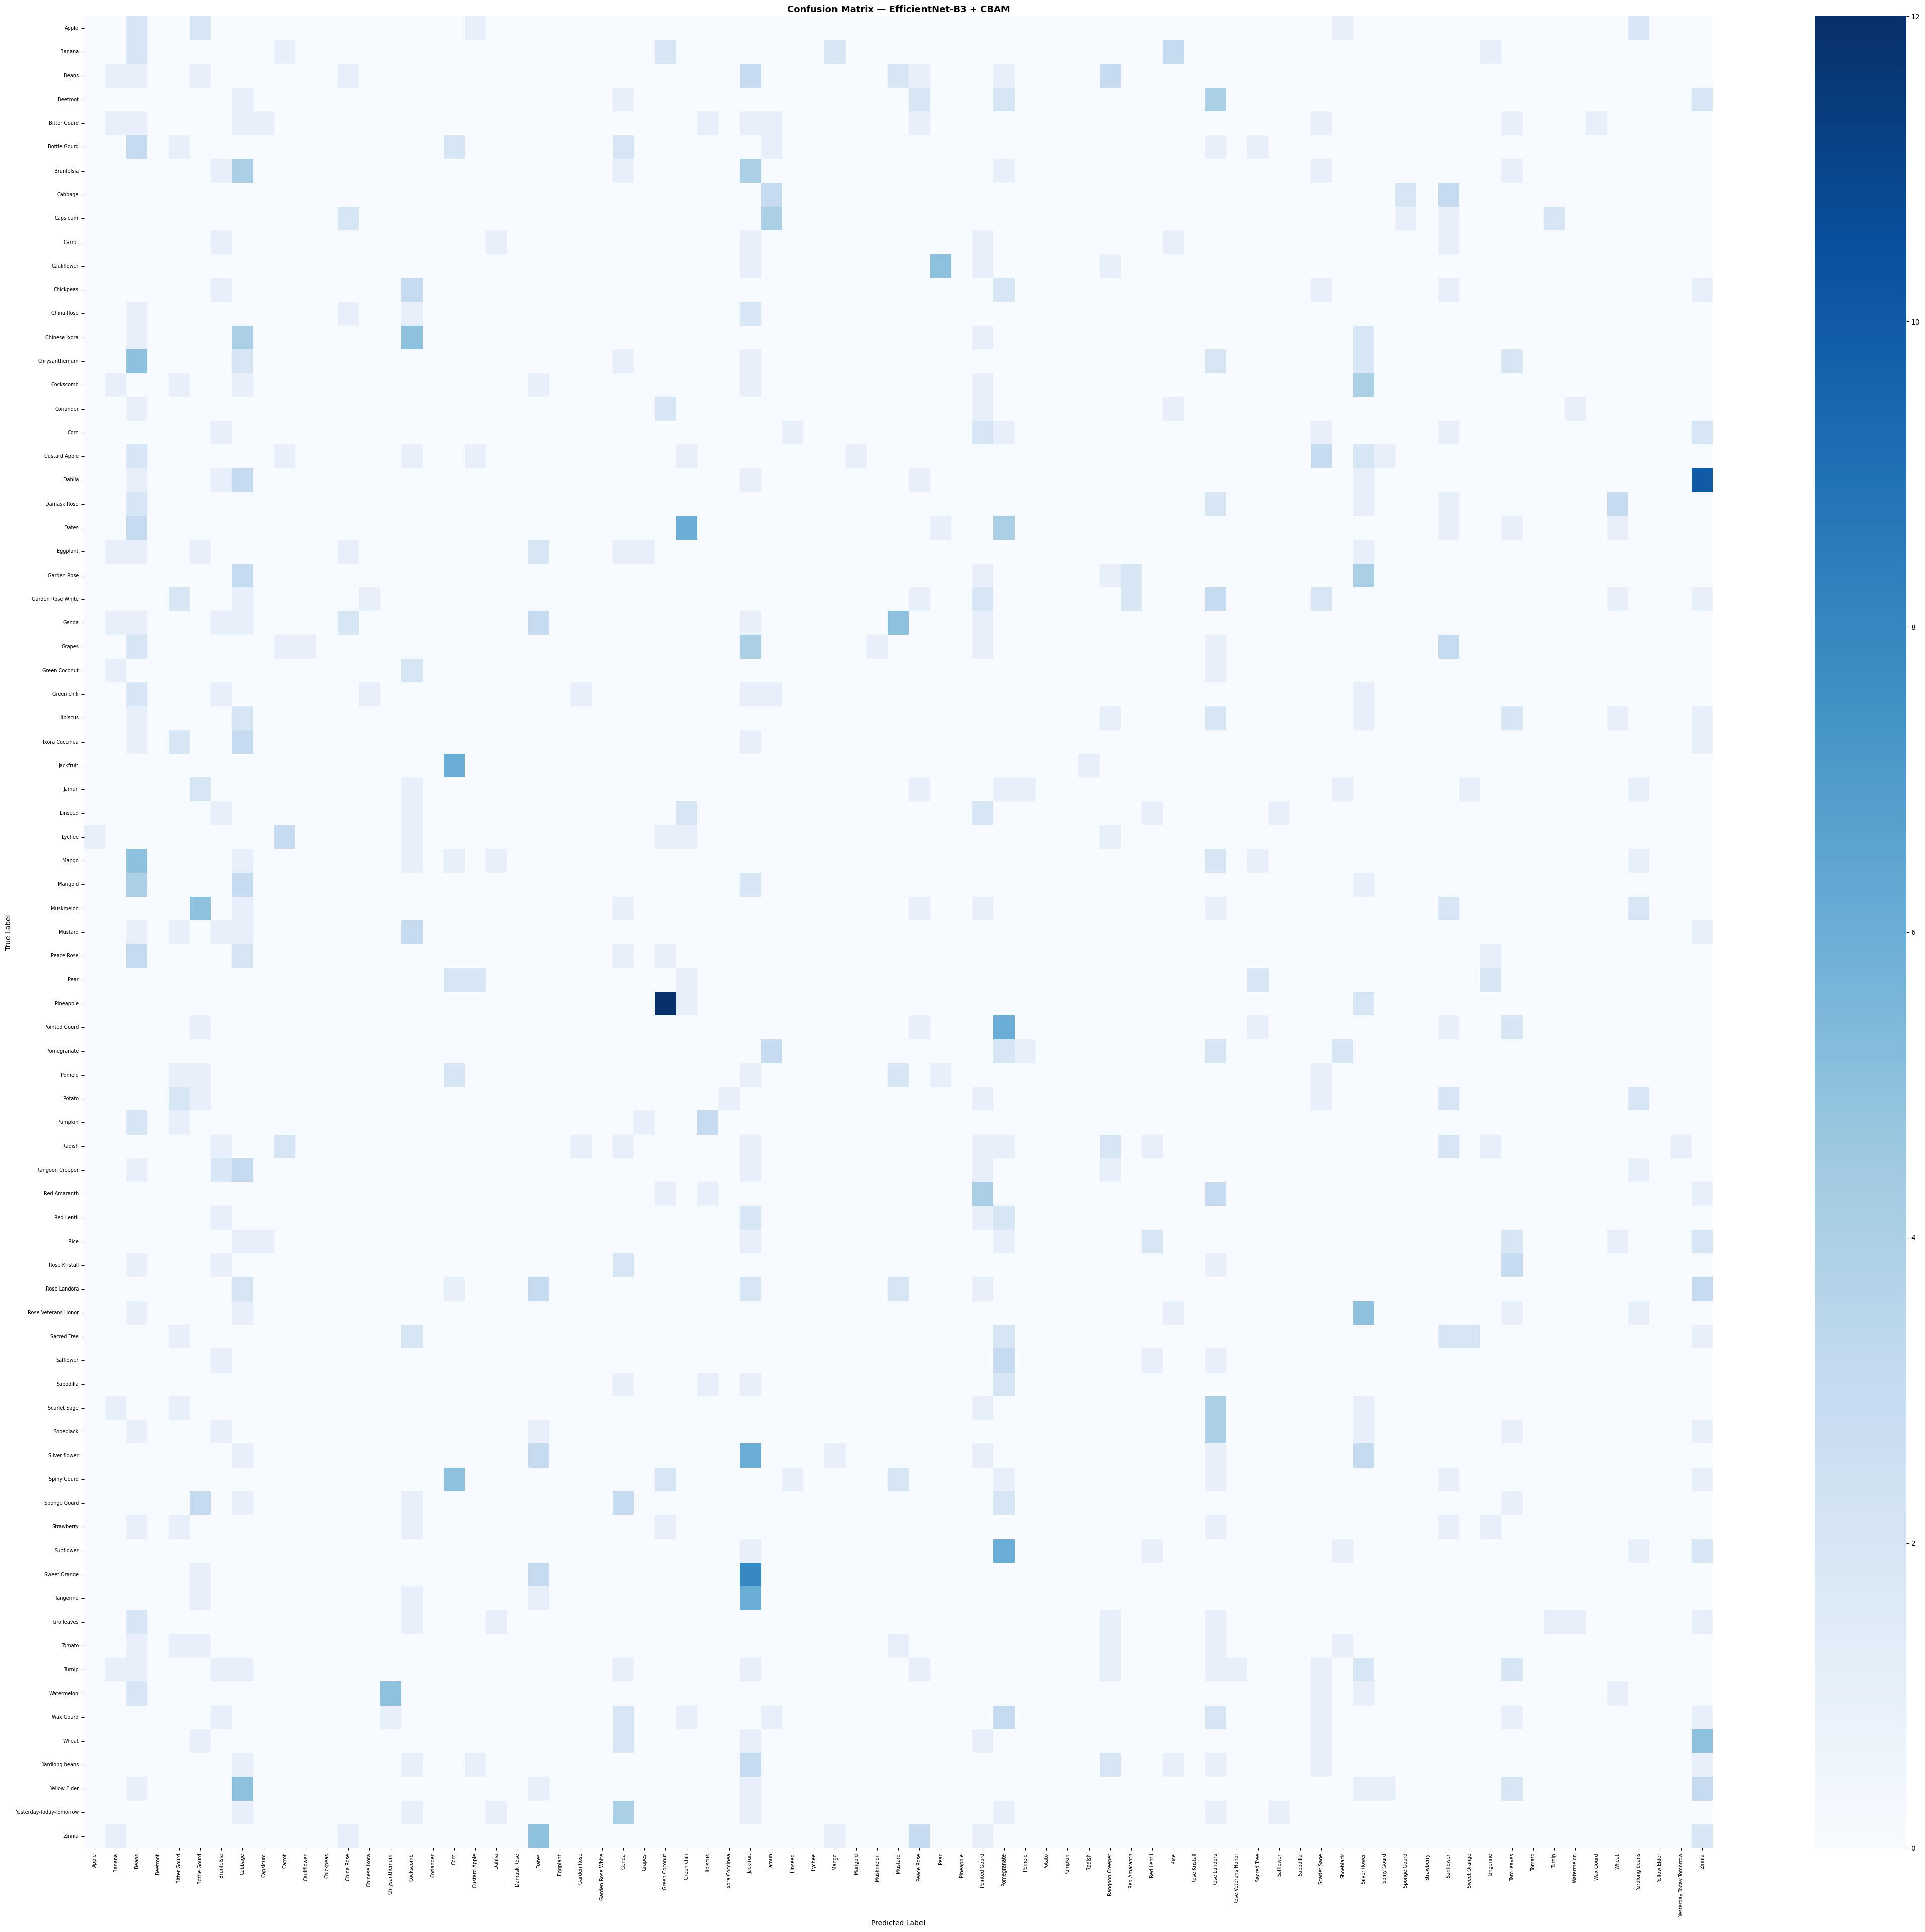

  ResNet-50  —  Evaluation Metrics
  Top-1 Accuracy       : 1.97 %
  Precision (macro)    : 0.0064
  Recall    (macro)    : 0.0182
  F1-Score  (macro)    : 0.0071
  Precision (weighted) : 0.0083
  Recall    (weighted) : 0.0197
  F1-Score  (weighted) : 0.0088

Per-Class Report — ResNet-50

                          precision    recall  f1-score   support

                   Apple      0.000     0.000     0.000         8
                  Banana      0.000     0.000     0.000        11
                   Beans      0.000     0.000     0.000        14
                Beetroot      0.000     0.000     0.000        12
            Bitter Gourd      0.000     0.000     0.000        11
            Bottle Gourd      0.000     0.000     0.000        11
              Brunfelsia      0.000     0.000     0.000        13
                 Cabbage      0.000     0.000     0.000         8
                Capsicum      0.023     0.300     0.043        10
                  Carrot      0.000     0.000    

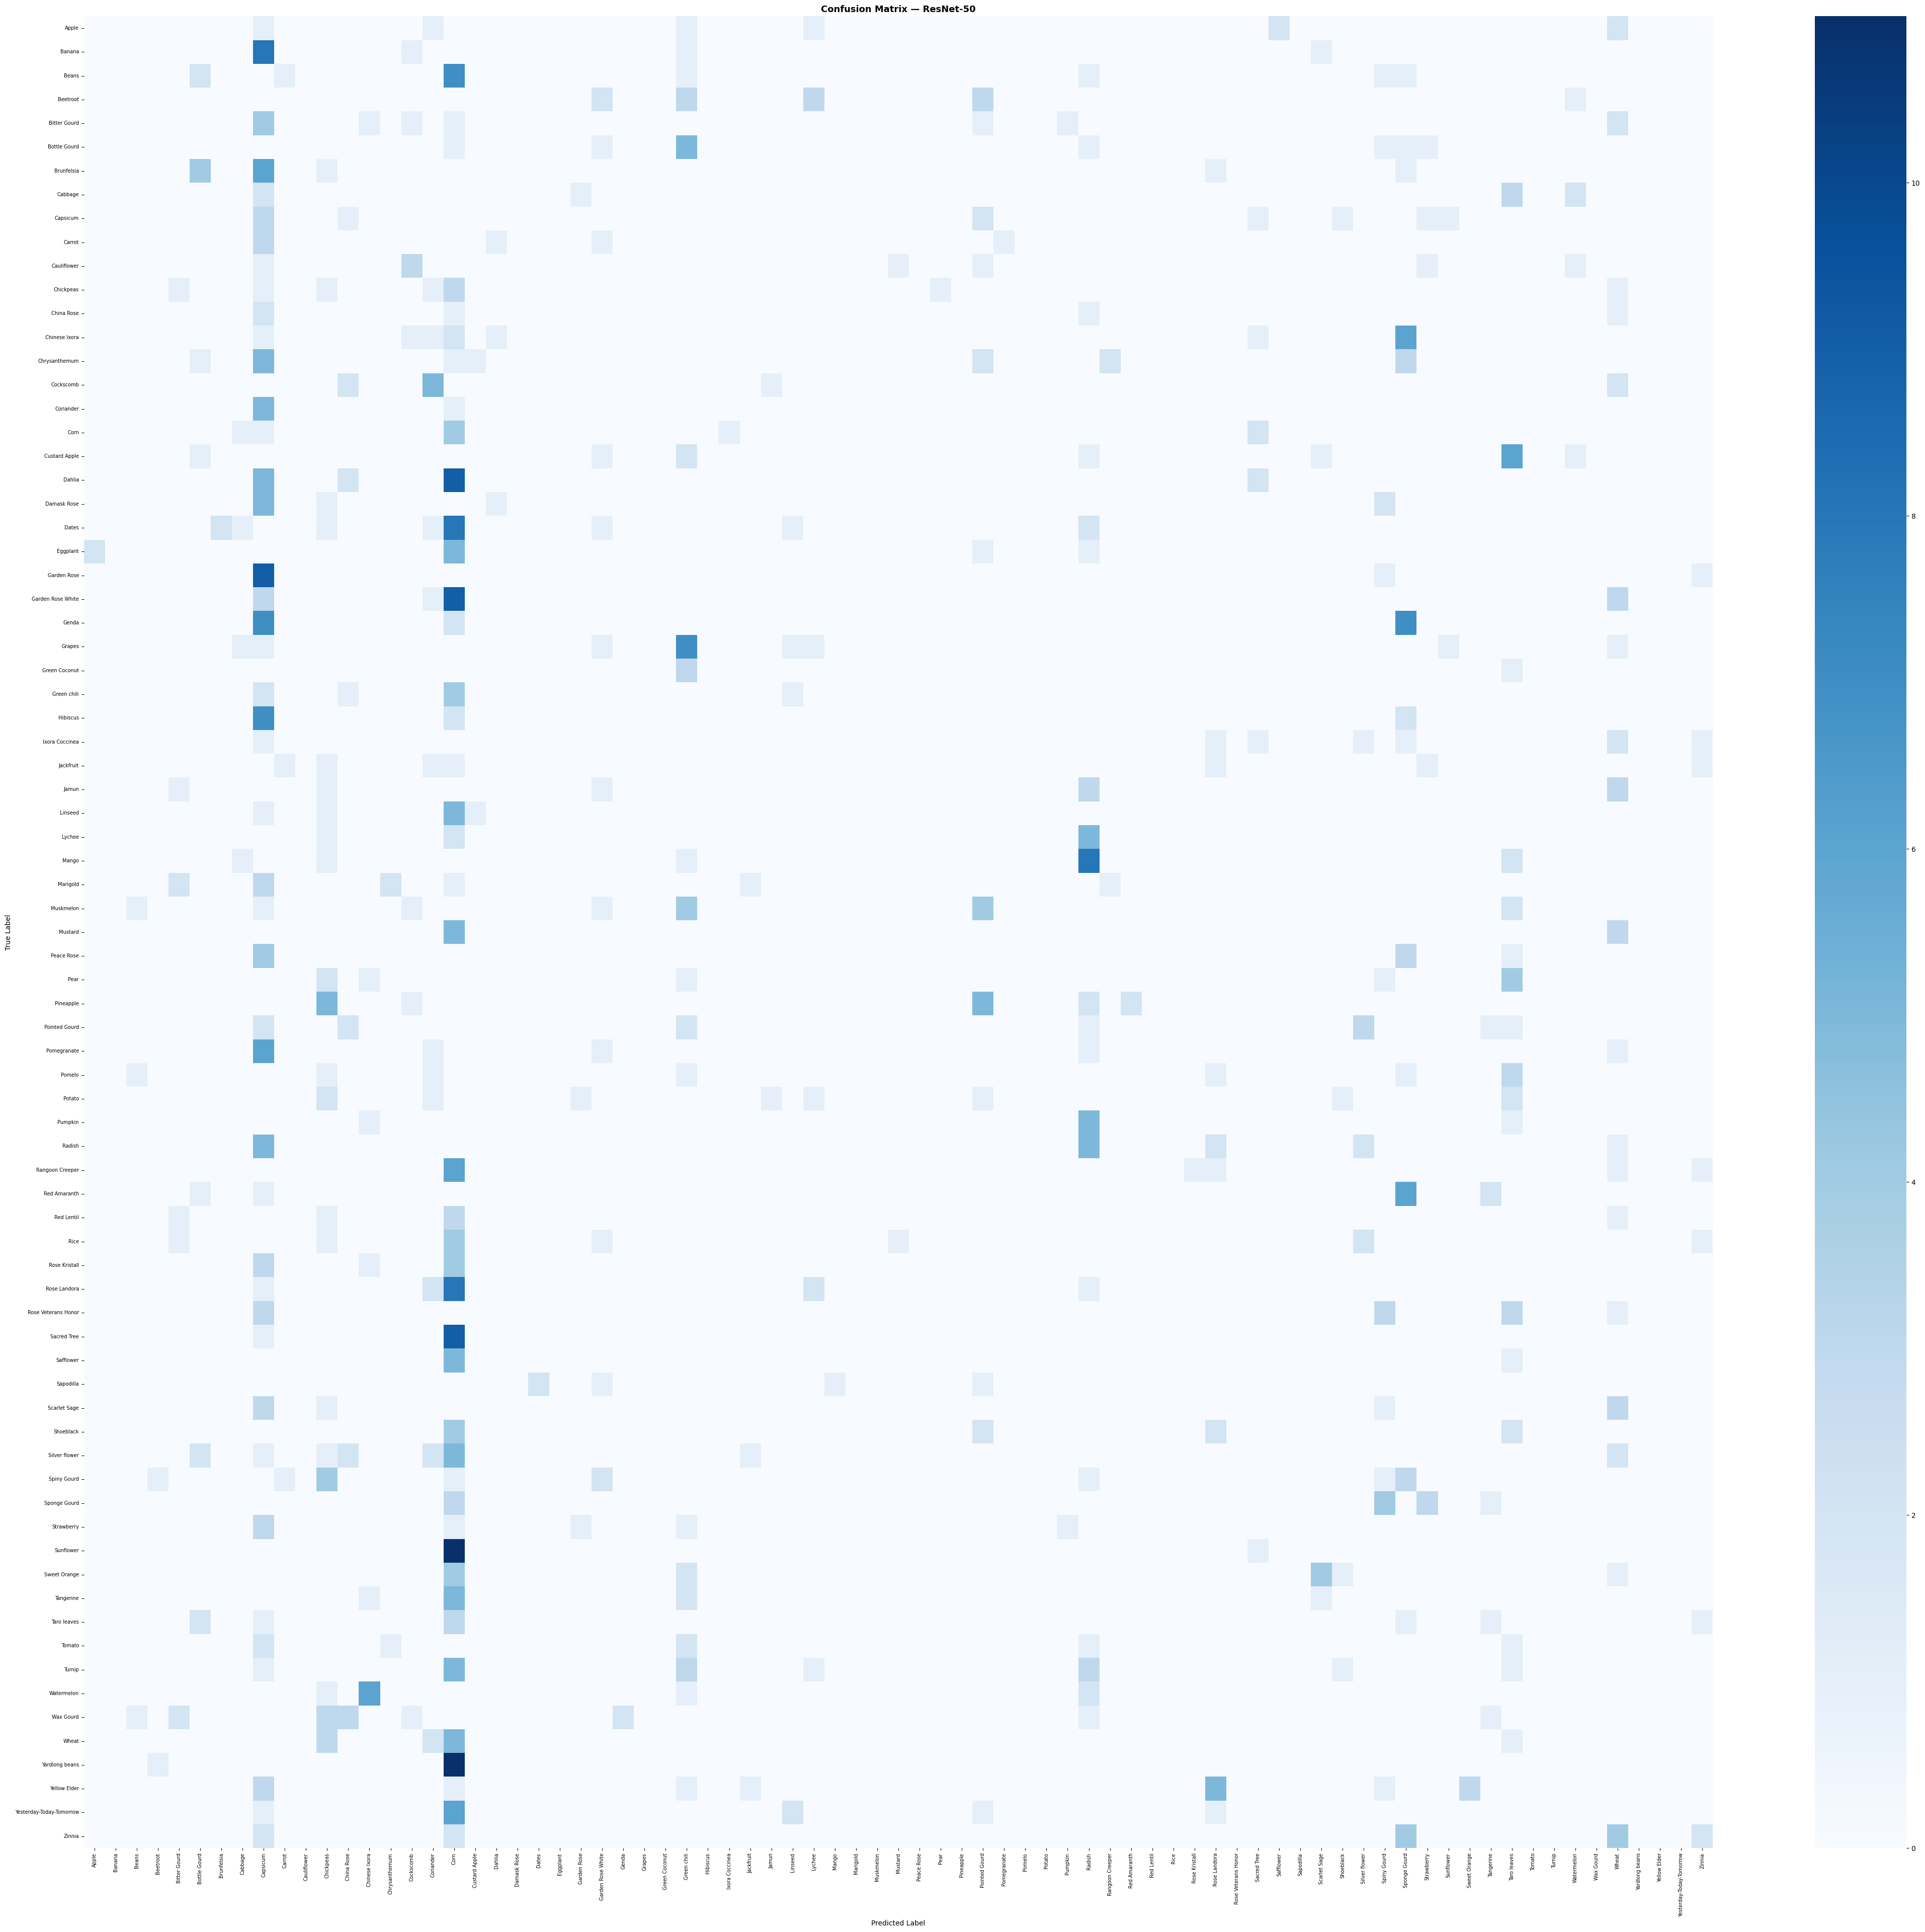

  VGG-16  —  Evaluation Metrics
  Top-1 Accuracy       : 0.37 %
  Precision (macro)    : 0.0019
  Recall    (macro)    : 0.0047
  F1-Score  (macro)    : 0.0025
  Precision (weighted) : 0.0015
  Recall    (weighted) : 0.0037
  F1-Score  (weighted) : 0.0020

Per-Class Report — VGG-16

                          precision    recall  f1-score   support

                   Apple      0.000     0.000     0.000         8
                  Banana      0.000     0.000     0.000        11
                   Beans      0.000     0.000     0.000        14
                Beetroot      0.000     0.000     0.000        12
            Bitter Gourd      0.000     0.000     0.000        11
            Bottle Gourd      0.000     0.000     0.000        11
              Brunfelsia      0.000     0.000     0.000        13
                 Cabbage      0.000     0.000     0.000         8
                Capsicum      0.000     0.000     0.000        10
                  Carrot      0.000     0.000     0.000

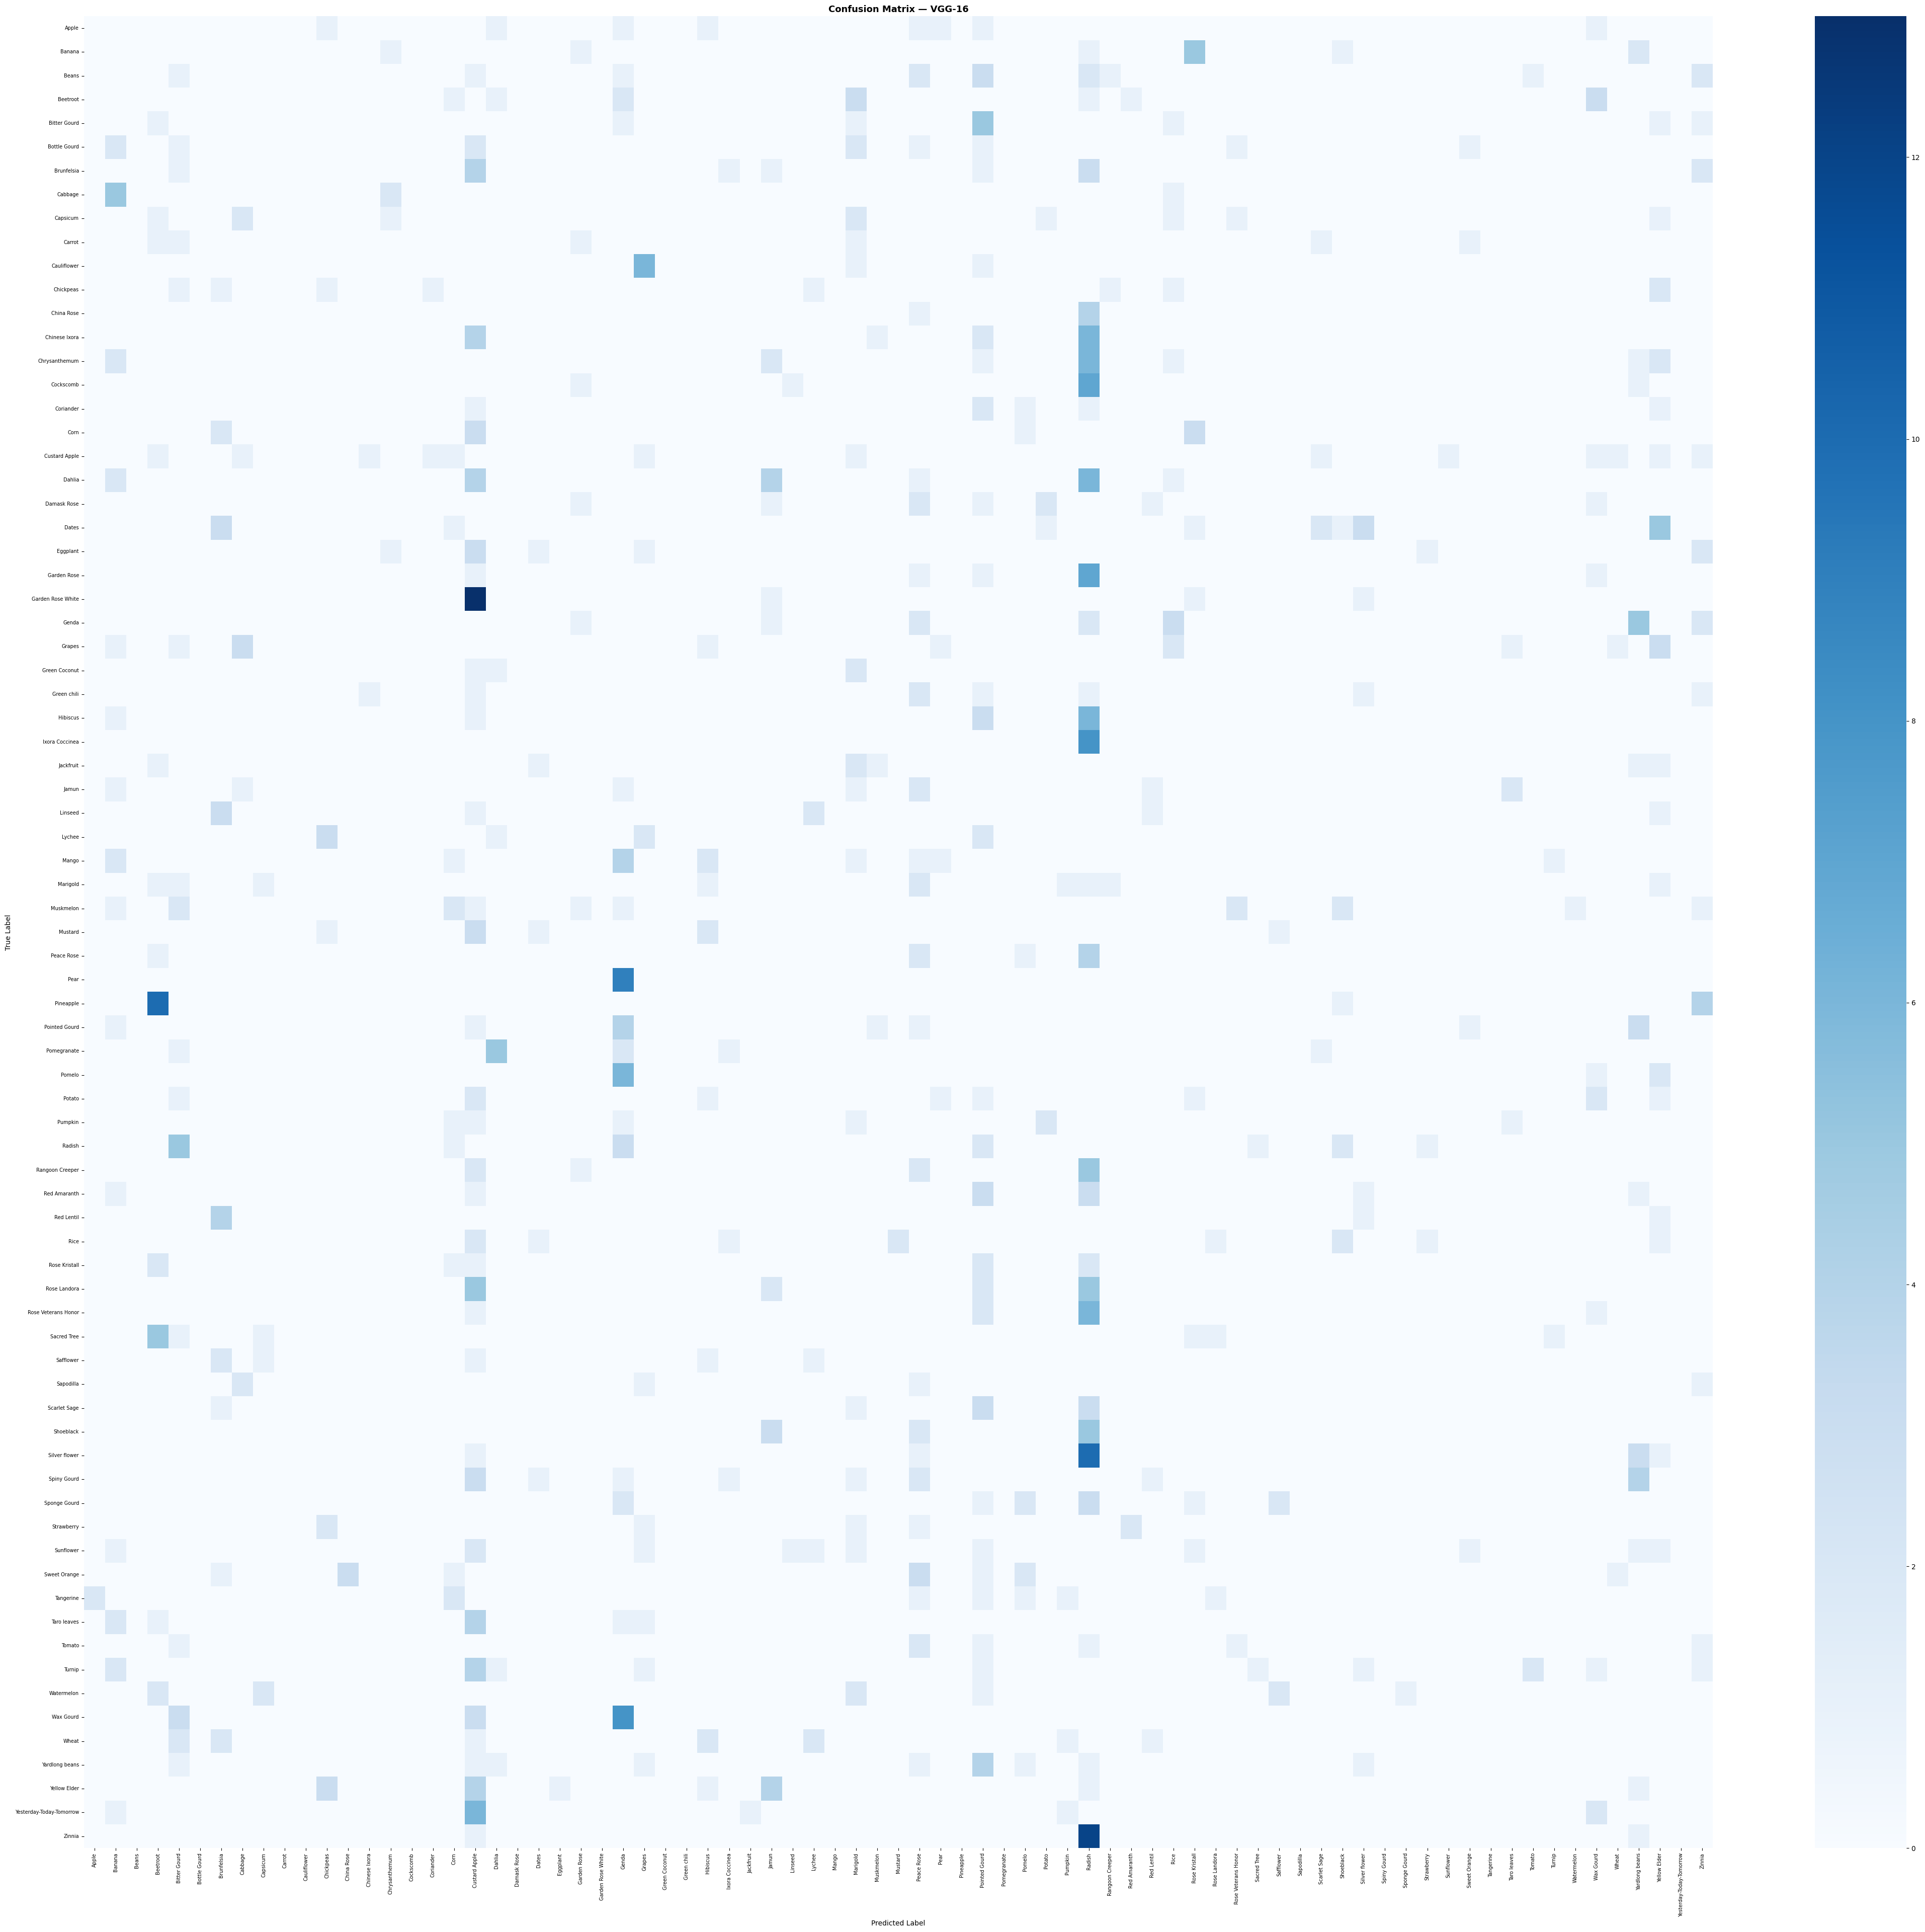

  MobileNetV3-Large  —  Evaluation Metrics
  Top-1 Accuracy       : 1.11 %
  Precision (macro)    : 0.0069
  Recall    (macro)    : 0.0112
  F1-Score  (macro)    : 0.0085
  Precision (weighted) : 0.0068
  Recall    (weighted) : 0.0111
  F1-Score  (weighted) : 0.0084

Per-Class Report — MobileNetV3-Large

                          precision    recall  f1-score   support

                   Apple      0.000     0.000     0.000         8
                  Banana      0.071     0.091     0.080        11
                   Beans      0.000     0.000     0.000        14
                Beetroot      0.042     0.083     0.056        12
            Bitter Gourd      0.083     0.091     0.087        11
            Bottle Gourd      0.000     0.000     0.000        11
              Brunfelsia      0.000     0.000     0.000        13
                 Cabbage      0.000     0.000     0.000         8
                Capsicum      0.000     0.000     0.000        10
                  Carrot      0.0

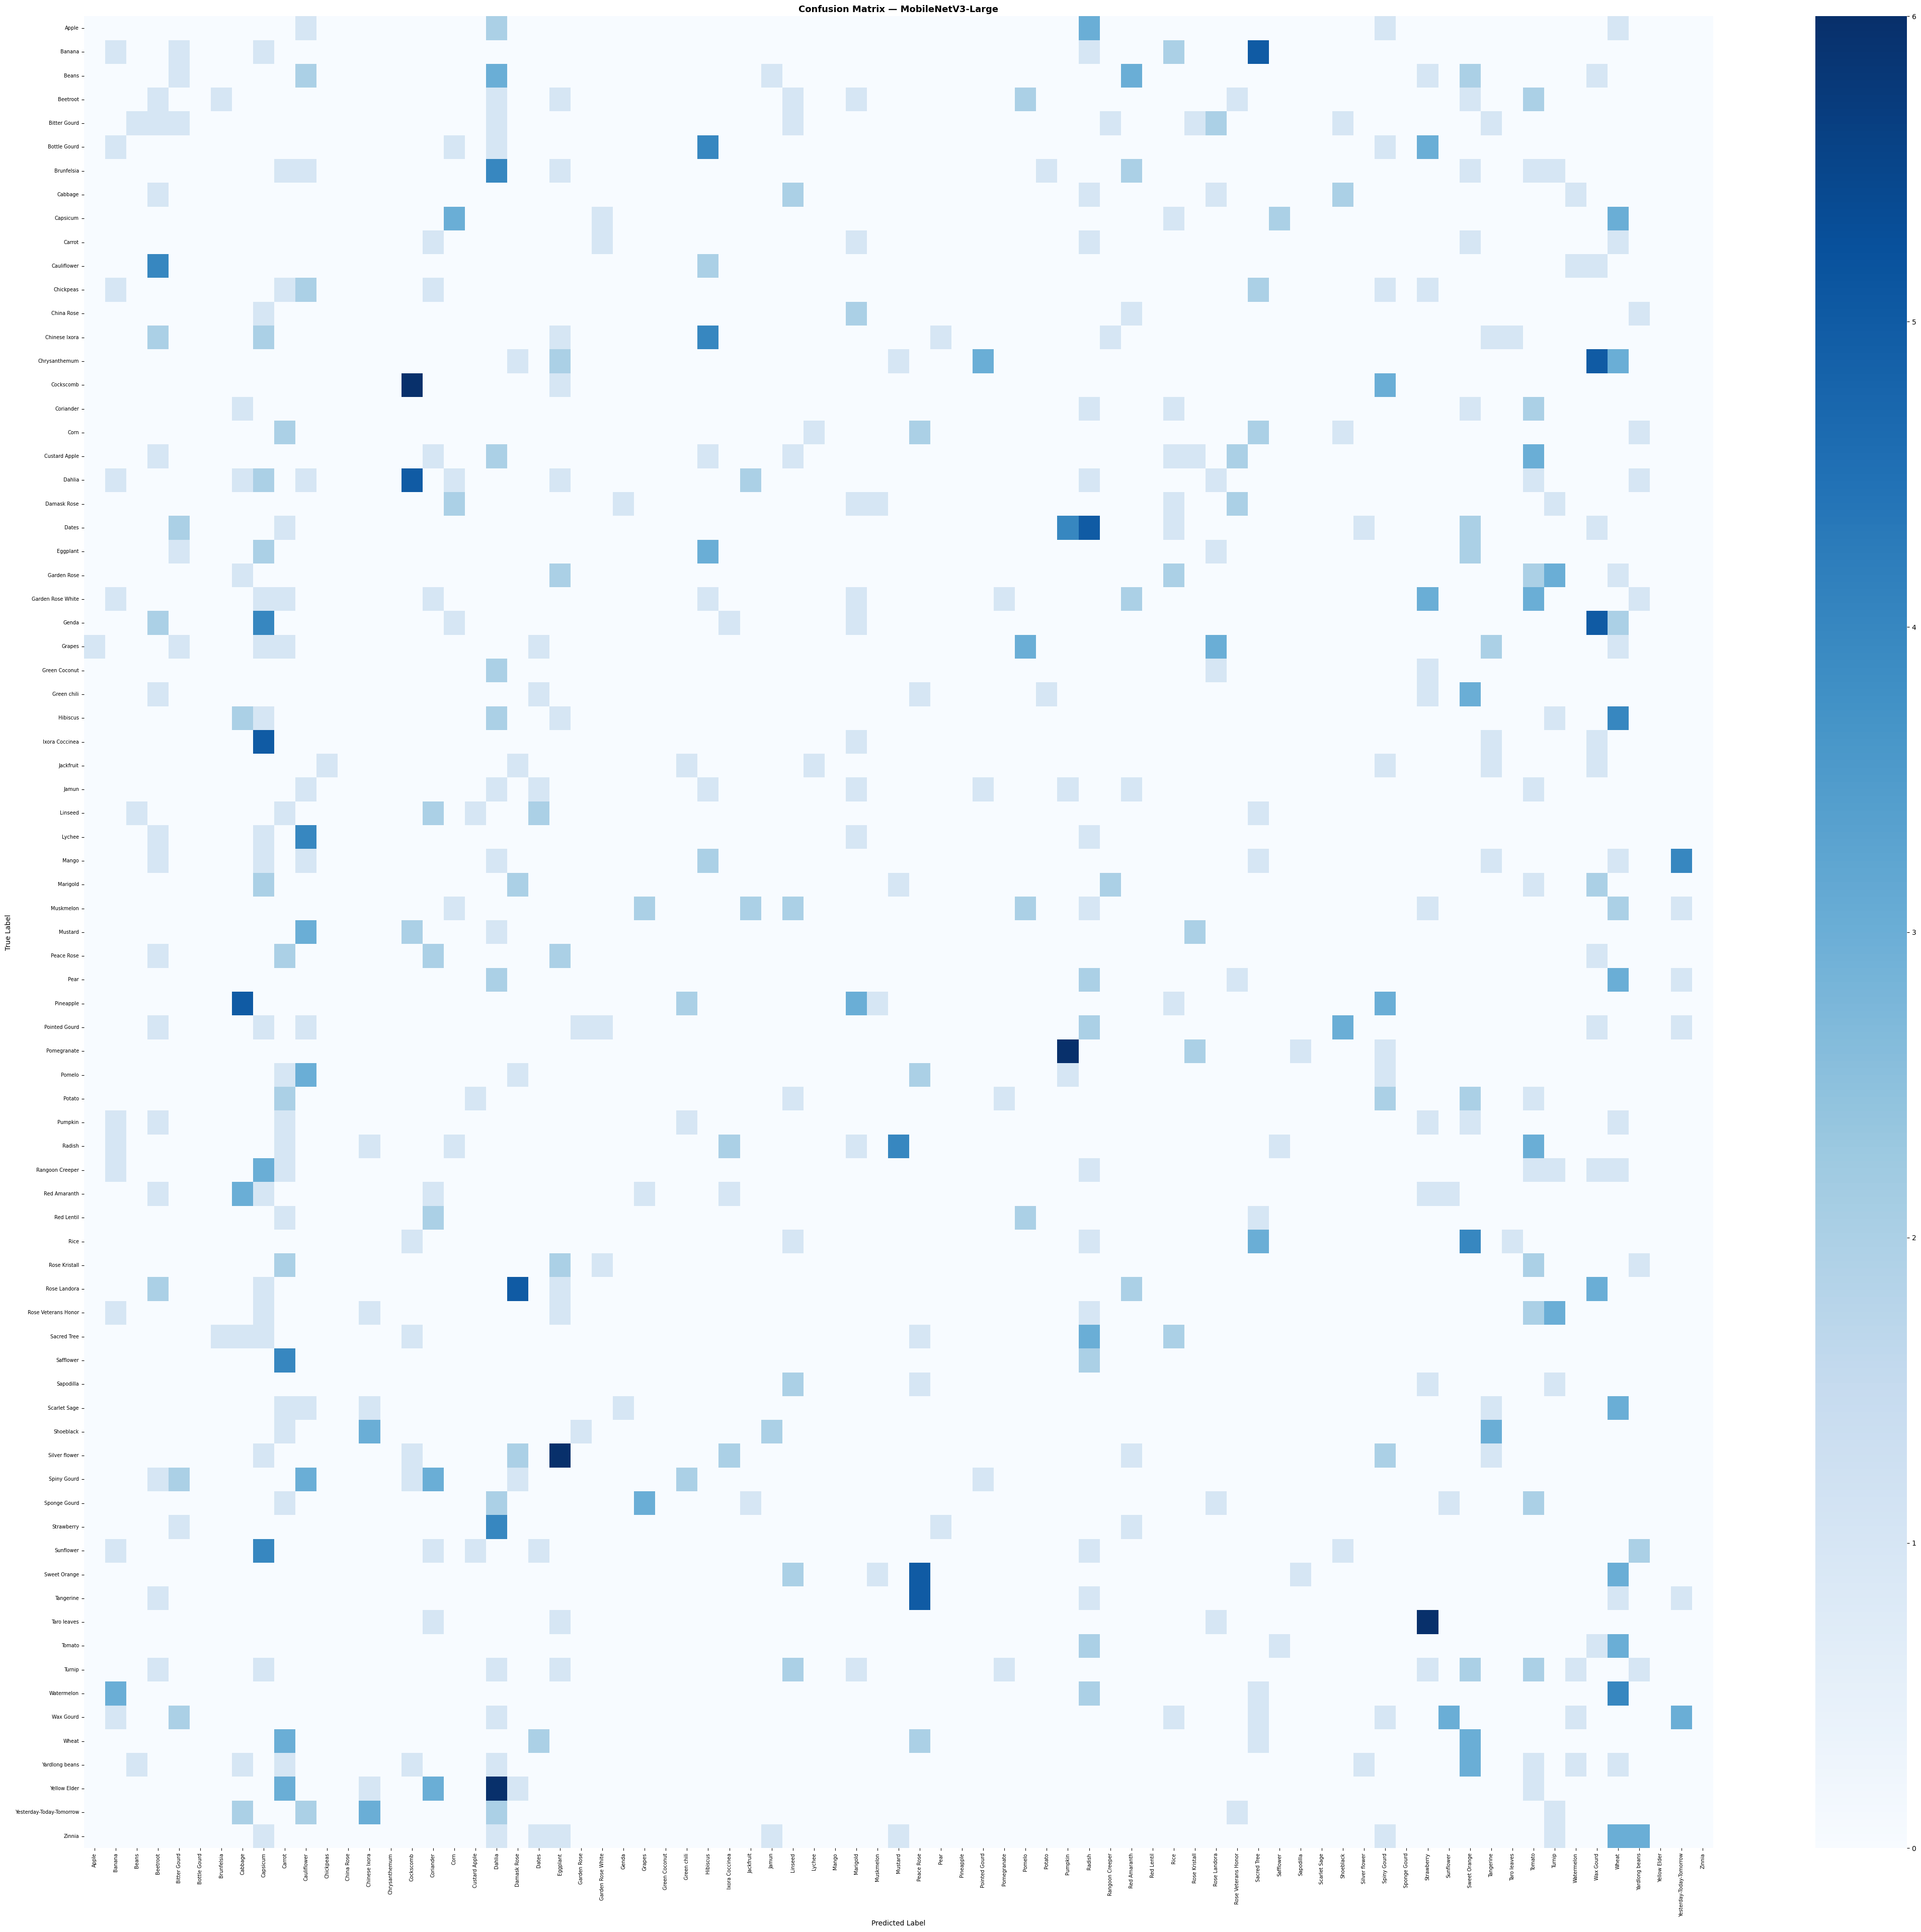


  Model Comparison Summary
                 Model Top-1 Accuracy Precision (macro) Recall (macro) F1 (macro) F1 (weighted)
EfficientNet-B3 + CBAM          1.48%            0.0083         0.0137     0.0090        0.0096
             ResNet-50          1.97%            0.0064         0.0182     0.0071        0.0088
                VGG-16          0.37%            0.0019         0.0047     0.0025        0.0020
     MobileNetV3-Large          1.11%            0.0069         0.0112     0.0085        0.0084


In [21]:
# ── Run metrics on your models and build a comparison table ─────────────────
# Evaluates on test_loader by default — swap in val_loader if you prefer.

results = []

# Your EfficientNet-B3 + CBAM + FCHead model (variable `model` from earlier)
results.append(evaluate_metrics(model, test_loader, CLASS_NAMES, model_name="EfficientNet-B3 + CBAM"))

# Baselines (only evaluate ones you've actually trained — untrained backbones
# with a fresh random head will score near-chance, so train first)
results.append(evaluate_metrics(model_resnet50,      test_loader, CLASS_NAMES, model_name="ResNet-50"))
results.append(evaluate_metrics(model_vgg16,         test_loader, CLASS_NAMES, model_name="VGG-16"))
results.append(evaluate_metrics(model_mobilenetv3,   test_loader, CLASS_NAMES, model_name="MobileNetV3-Large"))

# ── Summary comparison table ─────────────────────────────────────────────
import pandas as pd

summary_df = pd.DataFrame([
    {
        "Model": r["model_name"],
        "Top-1 Accuracy": f"{r['accuracy']*100:.2f}%",
        "Precision (macro)": f"{r['precision_macro']:.4f}",
        "Recall (macro)": f"{r['recall_macro']:.4f}",
        "F1 (macro)": f"{r['f1_macro']:.4f}",
        "F1 (weighted)": f"{r['f1_weighted']:.4f}",
    }
    for r in results
])

print("\n" + "=" * 70)
print("  Model Comparison Summary")
print("=" * 70)
print(summary_df.to_string(index=False))


#Ablation Study — Remove CBAM
Isolates the attention module's contribution by training two otherwise identical models — same EfficientNet-B3 backbone, same unfreeze strategy, same FCHead — where the only difference is whether CBAM is active or replaced with an identity (no-op). Everything else (data, loss, optimizer schedule, epochs, seed) is held constant so any accuracy/F1 gap can be attributed to CBAM itself.

In [22]:
# ── Ablation Model: CBAM vs. No-CBAM (identical everything else) ────────────
# Reuses the CBAM and FCHead classes already defined above — the ONLY
# structural difference between the two variants is `use_cbam`.

class EfficientNetB3_Ablation(nn.Module):
    """
    EfficientNet-B3 + optional CBAM + FCHead.
    Set use_cbam=False to replace CBAM with nn.Identity() — everything
    else (backbone, unfreeze strategy, head architecture) stays identical,
    isolating CBAM's contribution.
    """
    def __init__(self, num_classes, use_cbam=True, unfreeze_from=6,
                 hidden_dims=[512, 256], dropout_rates=[0.4, 0.3],
                 reduction_ratio=16):
        super().__init__()

        weights  = EfficientNet_B3_Weights.IMAGENET1K_V1
        backbone = efficientnet_b3(weights=weights)

        # Same freeze/unfreeze strategy as the main model
        for param in backbone.parameters():
            param.requires_grad = False
        for i, block in enumerate(backbone.features):
            if i >= unfreeze_from:
                for param in block.parameters():
                    param.requires_grad = True

        self.features = backbone.features
        self.cbam     = CBAM(in_channels=1536, reduction_ratio=reduction_ratio) if use_cbam else nn.Identity()
        self.avgpool  = backbone.avgpool
        self.fc_head  = FCHead(
            in_features   = 1536,
            num_classes   = num_classes,
            hidden_dims   = hidden_dims,
            dropout_rates = dropout_rates,
            use_bn        = True,
        )
        self.use_cbam = use_cbam

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc_head(x)
        return x


# ── Build both variants with the SAME seed (fair init comparison) ──────────
torch.manual_seed(42)
model_with_cbam = EfficientNetB3_Ablation(NUM_CLASSES, use_cbam=True).to(device)

torch.manual_seed(42)
model_no_cbam = EfficientNetB3_Ablation(NUM_CLASSES, use_cbam=False).to(device)

print_param_summary("Ablation — WITH CBAM", model_with_cbam)
print_param_summary("Ablation — NO CBAM",   model_no_cbam)

cbam_param_count = sum(p.numel() for p in model_with_cbam.cbam.parameters())
print(f"\n🎯 CBAM adds exactly {cbam_param_count:,} parameters — the only structural difference above.")


       Ablation — WITH CBAM  —  Parameter Summary
  Total params     :   11,930,071
  Trainable params :    9,739,917  ✅
  Frozen params    :    2,190,154  🔒
  Trainable ratio  :        81.6 %
       Ablation — NO CBAM  —  Parameter Summary
  Total params     :   11,635,061
  Trainable params :    9,444,907  ✅
  Frozen params    :    2,190,154  🔒
  Trainable ratio  :        81.2 %

🎯 CBAM adds exactly 295,010 parameters — the only structural difference above.


Training WITH CBAM …



[With CBAM] Epoch 1/15:   0%|          | 0/119 [00:00<?, ?it/s]

  [With CBAM] Epoch  1/15 — train_loss 5.9029 | val_loss 4.8037 | val_acc 2.47%


[With CBAM] Epoch 2/15:   0%|          | 0/119 [00:00<?, ?it/s]

  [With CBAM] Epoch  2/15 — train_loss 5.5721 | val_loss 4.3147 | val_acc 5.31%


...

  [No CBAM] Epoch 13/15 — train_loss 2.1852 | val_loss 1.4465 | val_acc 86.54%


[No CBAM] Epoch 14/15:   0%|          | 0/119 [00:00<?, ?it/s]

  [No CBAM] Epoch 14/15 — train_loss 2.1574 | val_loss 1.4217 | val_acc 87.90%


[No CBAM] Epoch 15/15:   0%|          | 0/119 [00:00<?, ?it/s]

  [No CBAM] Epoch 15/15 — train_loss 2.1385 | val_loss 1.4105 | val_acc 86.91%
  With CBAM  —  Evaluation Metrics
  Top-1 Accuracy       : 87.32 %
  Precision (macro)    : 0.8791
  Recall    (macro)    : 0.8775
  F1-Score  (macro)    : 0.8643
  Precision (weighted) : 0.8909
  Recall    (weighted) : 0.8732
  F1-Score  (weighted) : 0.8674

Per-Class Report — With CBAM

                          precision    recall  f1-score   support

                   Apple      1.000     1.000     1.000         8
                  Banana      0.917     1.000     0.957        11
                   Beans      0.833     0.357     0.500        14
                Beetroot      0.923     1.000     0.960        12
            Bitter Gourd      1.000     1.000     1.000        11
            Bottle Gourd      0.909     0.909     0.909        11
              Brunfelsia      0.867     1.000     0.929        13
                 Cabbage      0.800     1.000     0.889         8
                Capsicum      1.000

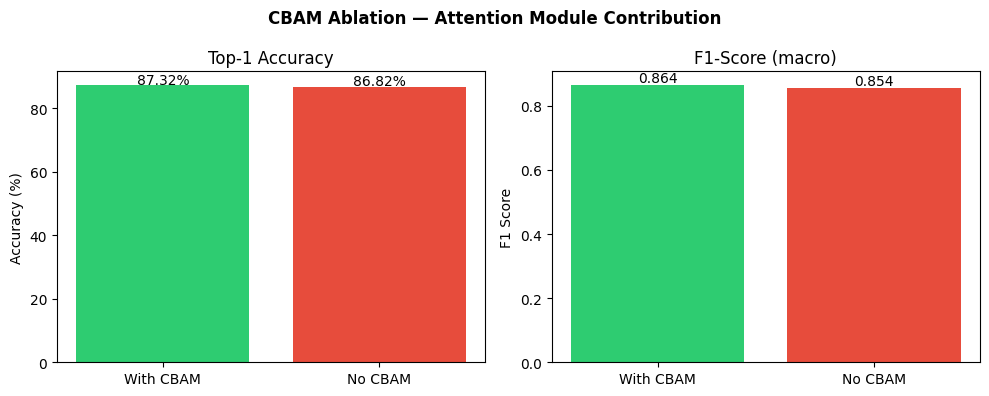

In [23]:
# ── Train both variants under IDENTICAL settings, then compare ──────────────
import copy

def train_model(model, train_loader, val_loader, num_epochs,
                 lr_backbone=1e-5, lr_head=1e-4, weight_decay=1e-4,
                 label_smoothing=0.1, class_weights=None,
                 model_name="Model", patience=5):
    """
    Generic training loop with differential LR (backbone vs. rest),
    warmup→cosine schedule, label-smoothing CE, and early stopping on
    val accuracy. Returns the model loaded with its best-val-acc weights.
    """
    criterion = LabelSmoothingCrossEntropy(
        num_classes=NUM_CLASSES, smoothing=label_smoothing,
        weight=class_weights, reduction="mean",
    )

    backbone_params = [p for p in model.features.parameters() if p.requires_grad]
    other_params    = [p for n, p in model.named_parameters()
                        if not n.startswith("features.") and p.requires_grad]

    optimizer = optim.AdamW([
        {"params": backbone_params, "lr": lr_backbone, "weight_decay": weight_decay},
        {"params": other_params,    "lr": lr_head,     "weight_decay": weight_decay},
    ])

    warmup  = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=min(3, num_epochs))
    cosine  = CosineAnnealingLR(optimizer, T_max=max(num_epochs - 3, 1), eta_min=1e-6)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[min(3, num_epochs)])

    best_val_acc, best_state, epochs_no_improve = 0.0, None, 0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch+1}/{num_epochs}", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        scheduler.step()
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs)
                val_loss += criterion(logits, labels).item() * imgs.size(0)
                correct  += (logits.argmax(1) == labels).sum().item()
                total    += labels.size(0)
        val_loss /= len(val_loader.dataset)
        val_acc   = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"  [{model_name}] Epoch {epoch+1:>2}/{num_epochs} — "
              f"train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_acc {val_acc*100:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc, best_state, epochs_no_improve = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  ⏹  Early stopping — no val improvement for {patience} epochs.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


# ── Run the ablation ─────────────────────────────────────────────────────
NUM_EPOCHS_ABLATION = 15  # shorter than full training is fine for a controlled A/B

print("Training WITH CBAM …\n")
model_with_cbam, hist_with = train_model(
    model_with_cbam, train_loader, val_loader,
    num_epochs=NUM_EPOCHS_ABLATION, class_weights=class_weights, model_name="With CBAM",
)

print("\nTraining NO CBAM …\n")
model_no_cbam, hist_no = train_model(
    model_no_cbam, train_loader, val_loader,
    num_epochs=NUM_EPOCHS_ABLATION, class_weights=class_weights, model_name="No CBAM",
)

# ── Evaluate both on the held-out test set ──────────────────────────────
metrics_with = evaluate_metrics(model_with_cbam, test_loader, CLASS_NAMES, model_name="With CBAM", plot_cm=False)
metrics_no   = evaluate_metrics(model_no_cbam,   test_loader, CLASS_NAMES, model_name="No CBAM (Ablation)", plot_cm=False)

acc_drop = (metrics_with["accuracy"] - metrics_no["accuracy"]) * 100
f1_drop  = metrics_with["f1_macro"] - metrics_no["f1_macro"]

print("\n" + "=" * 58)
print("  CBAM Ablation Result")
print("=" * 58)
print(f"  Top-1 Accuracy  WITH CBAM : {metrics_with['accuracy']*100:.2f}%")
print(f"  Top-1 Accuracy  NO  CBAM  : {metrics_no['accuracy']*100:.2f}%")
print(f"  → Accuracy drop from removing CBAM : {acc_drop:.2f} pp")
print(f"\n  F1 (macro)  WITH CBAM     : {metrics_with['f1_macro']:.4f}")
print(f"  F1 (macro)  NO  CBAM      : {metrics_no['f1_macro']:.4f}")
print(f"  → F1 (macro) drop from removing CBAM : {f1_drop:.4f}")
print("=" * 58)

# ── Bar chart: with vs. without CBAM ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["With CBAM", "No CBAM"],
            [metrics_with["accuracy"]*100, metrics_no["accuracy"]*100],
            color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Top-1 Accuracy")
axes[0].set_ylabel("Accuracy (%)")
for i, v in enumerate([metrics_with["accuracy"]*100, metrics_no["accuracy"]*100]):
    axes[0].text(i, v + 0.5, f"{v:.2f}%", ha="center")

axes[1].bar(["With CBAM", "No CBAM"],
            [metrics_with["f1_macro"], metrics_no["f1_macro"]],
            color=["#2ecc71", "#e74c3c"])
axes[1].set_title("F1-Score (macro)")
axes[1].set_ylabel("F1 Score")
for i, v in enumerate([metrics_with["f1_macro"], metrics_no["f1_macro"]]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center")

fig.suptitle("CBAM Ablation — Attention Module Contribution", fontweight="bold")
plt.tight_layout()
plt.show()
